# Measles Epidemiology in Bangladesh
## Exploratory Data Analysis

> **Data last updated:** see Section 0 for automatic date stamp.

### Three-part structure

| Part | Period | Focus |
|------|--------|-------|
| I | 2000–2011 | Impact of the first measles dose (MCV1) |
| II | 2012–2025 | Impact of adding the second dose (MCV2) |
| III | 2026 | The current outbreak — what happened and why |

**Sources**
- WHO GHO indicator `WHS3_62` — reported measles cases 1975–2024
- WHO GHO indicator `WHS8_110` — MCV1 WHO estimate 2000–2024
- WHO GHO indicator `MCV2` — MCV2 WHO estimate 2012–2024
- Original multi-source coverage data (admin / official / WHO) from DGHS/JRF
- 2026 outbreak: DGHS hospital sentinel surveillance, as of 20 April 2026 (latest available)


## 0. Environment Setup & Data Stamp

In [1]:
import os, warnings, datetime
import numpy  as np
import pandas as pd
import matplotlib.pyplot   as plt
import matplotlib.ticker   as mticker
import matplotlib.patches  as mpatches
import matplotlib.colors   as mcolors
import matplotlib.patheffects as pe
import seaborn as sns
import geopandas as gpd
from scipy import stats
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

# Enable full LaTeX rendering for publication-quality text
plt.rcParams.update({
    'text.usetex'        : True,
    'font.family'        : 'serif',
    'text.latex.preamble': r'\usepackage{amsmath}\usepackage{amssymb}',
})

# ── Paths ─────────────────────────────────────────────────────────
PROCESSED = 'data/processed/measles_bangladesh_consolidated.xlsx'
SHP_ADM1  = ('data/bgd_adm_bbs_20201113_shp/bgd_adm_bbs_20201113_SHP/'
             'bgd_admbnda_adm1_bbs_20201113.shp')
FIG_DIR   = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

# ── Read data-update timestamp from the workbook ──────────────────
_log = pd.read_excel(PROCESSED, sheet_name='update_log')
_ts  = pd.to_datetime(_log['Updated'].iloc[-1])
DATA_DATE = _ts.strftime('%d %B %Y')
display(Markdown(f"### Data reflects: **{DATA_DATE}**"))
print(f"Consolidated workbook: {PROCESSED}")

# ── Seaborn theme ─────────────────────────────────────────────────
sns.set_theme(
    context='paper', style='whitegrid', palette='colorblind',
    font='DejaVu Sans', font_scale=1.3,
    rc={
        'figure.facecolor'  : 'white',
        'axes.facecolor'    : 'white',
        'grid.alpha'        : 0.35,
        'grid.linestyle'    : '--',
        'axes.spines.top'   : False,
        'axes.spines.right' : False,
    }
)
DPI = 300

PAL   = sns.color_palette('colorblind')
BLUE, ORNG, GREEN, RED, PURP = PAL[0], PAL[1], PAL[2], PAL[3], PAL[4]

def savefig(name):
    path = f'{FIG_DIR}/{name}'
    plt.savefig(path, dpi=DPI, bbox_inches='tight')
    print(f"Saved → {path}")
    plt.show()


# ── Bangladesh national population (UN WPP 2024, absolute) ──────────────
BD_POP = {
    2000: 129_955_000, 2001: 131_639_000, 2002: 133_347_000,
    2003: 135_078_000, 2004: 136_829_000, 2005: 138_598_000,
    2006: 140_384_000, 2007: 142_186_000, 2008: 143_999_000,
    2009: 145_820_000, 2010: 147_645_000, 2011: 149_476_000,
    2012: 151_319_000, 2013: 153_176_000, 2014: 155_044_000,
    2015: 156_917_000, 2016: 158_791_000, 2017: 160_657_000,
    2018: 162_508_000, 2019: 164_336_000, 2020: 166_130_000,
    2021: 167_886_000, 2022: 169_600_000, 2023: 171_268_000,
    2024: 172_954_000, 2025: 174_701_000,
}

# ── BBS 2022 census — division populations ───────────────────────────────
DIV_POP_2022 = {
    'Dhaka'      : 44_310_000,
    'Chattogram' : 33_580_000,
    'Rajshahi'   : 20_340_000,
    'Khulna'     : 17_280_000,
    'Rangpur'    : 17_900_000,
    'Mymensingh' : 13_360_000,
    'Sylhet'     : 11_370_000,
    'Barisal'    :  9_380_000,
}

print("\nSetup complete.")


### Data reflects: **22 April 2026**

Consolidated workbook: data/processed/measles_bangladesh_consolidated.xlsx

Setup complete.


## Load & Preview Datasets

In [2]:
xl = pd.ExcelFile(PROCESSED)

# ── Raw source tables ─────────────────────────────────────────────
cases_full  = pd.read_excel(PROCESSED, sheet_name='cases_full')
mcv1_cov    = pd.read_excel(PROCESSED, sheet_name='mcv1_coverage')
mcv2_cov    = pd.read_excel(PROCESSED, sheet_name='mcv2_coverage')
cases_full['Year'] = cases_full['Year'].astype(int)
mcv1_cov['Year']   = mcv1_cov['Year'].astype(int)
mcv2_cov['Year']   = mcv2_cov['Year'].astype(int)

# ── Build analysis table (join of source tables, 2000-2024) ──────
# cases_full runs 1975-2024; slice to analysis window
analysis = (
    cases_full[cases_full['Year'].between(2000, 2025)]
    [['Year','Reported_Cases_WHO']]
    .rename(columns={'Reported_Cases_WHO': 'Reported_Cases'})
    .merge(
        mcv1_cov[['Year','MCV1_WHO_GHO_%','MCV1_Official_%','MCV1_Admin_%']]
        .rename(columns={'MCV1_WHO_GHO_%':'MCV1_WHO_%'}),
        on='Year', how='left')
    .merge(
        mcv2_cov[['Year','MCV2_WHO_GHO_%','MCV2_Official_%','MCV2_Admin_%']]
        .rename(columns={'MCV2_WHO_GHO_%':'MCV2_WHO_%'}),
        on='Year', how='left')
    .sort_values('Year').reset_index(drop=True)
)

# ── 2026 outbreak tables ──────────────────────────────────────────
outb_summary = pd.read_excel(PROCESSED, sheet_name='outbreak_2026_summary')
outb_div     = pd.read_excel(PROCESSED, sheet_name='outbreak_2026_divisions')
outb_dist    = pd.read_excel(PROCESSED, sheet_name='outbreak_2026_districts')

# ── Convenience sub-periods ───────────────────────────────────────
era1 = analysis[analysis['Year'].between(2000, 2011)].copy()
era2 = analysis[analysis['Year'].between(2012, 2025)].copy()

print(f'cases_full : {len(cases_full):>3} rows  '
      f'({int(cases_full.Year.min())}--{int(cases_full.Year.max())})')
print(f'mcv1_cov   : {len(mcv1_cov):>3} rows  '
      f'({int(mcv1_cov.Year.min())}--{int(mcv1_cov.Year.max())})')
print(f'mcv2_cov   : {len(mcv2_cov):>3} rows  '
      f'({int(mcv2_cov.Year.min())}--{int(mcv2_cov.Year.max())})')
print(f'analysis   : {len(analysis):>3} rows  (joined, 2000--2025)')
print(f'outb_div   : {len(outb_div):>3} rows  (8 divisions)')
print(f'outb_dist  : {len(outb_dist):>3} rows  (60 districts)')

# ── National incidence rate (per 100,000) ───────────────────────────────
analysis['Population']         = analysis['Year'].map(BD_POP)
analysis['Incidence_per_100k'] = (
    pd.to_numeric(analysis['Reported_Cases'], errors='coerce')
    / analysis['Population'] * 100_000
)
print(f'MCV1 era   : {len(era1):>3} rows  |  MCV2 era: {len(era2)} rows')


cases_full :  50 rows  (1975--2024)
mcv1_cov   :  26 rows  (2000--2025)
mcv2_cov   :  14 rows  (2012--2025)
analysis   :  25 rows  (joined, 2000--2025)
outb_div   :   8 rows  (8 divisions)
outb_dist  :  60 rows  (60 districts)
MCV1 era   :  12 rows  |  MCV2 era: 13 rows


---
## Dataset Overview
Summary of all data sources, their provenance, and descriptive statistics before analysis begins.

In [3]:
# ── Dataset Inventory Table ──────────────────────────────────────
inventory = pd.DataFrame([
    {'Sheet / Variable': 'cases_full',
     'Source': 'WHO GHO (WHS3\_62)',
     'Period': '1975--2024',
     'Rows': len(cases_full),
     'Key Variables': 'Year, Reported Cases'},
    {'Sheet / Variable': 'mcv1\_coverage',
     'Source': 'WHO GHO (WHS8\_110) + DGHS official',
     'Period': '2000--2025',
     'Rows': len(mcv1_cov),
     'Key Variables': 'MCV1 WHO, Official, Admin (\%)'},
    {'Sheet / Variable': 'mcv2\_coverage',
     'Source': 'WHO GHO (MCV2) + DGHS official',
     'Period': '2012--2025',
     'Rows': len(mcv2_cov),
     'Key Variables': 'MCV2 WHO, Official, Admin (\%)'},
    {'Sheet / Variable': 'outbreak\_2026\_divisions',
     'Source': 'DGHS hospital surveillance',
     'Period': 'Jan--Apr 2026',
     'Rows': len(outb_div),
     'Key Variables': 'Division, Cases, Deaths, CFR (\%)'},
    {'Sheet / Variable': 'outbreak\_2026\_districts',
     'Source': 'DGHS hospital surveillance',
     'Period': 'Jan--Apr 2026',
     'Rows': len(outb_dist),
     'Key Variables': 'District, Division, Cases, Deaths, CFR (\%)'},
])
display(Markdown('### Data Sources'))
display(inventory.to_string(index=False))

# ── Summary Statistics: Longitudinal (2000-2025) ──────────────────
display(Markdown(
    r'### Summary Statistics --- Longitudinal Dataset (2000--2025)'
))
desc_analysis = analysis[[
    'Reported_Cases','MCV1_WHO_%','MCV1_Official_%','MCV1_Admin_%',
    'MCV2_WHO_%','MCV2_Official_%','MCV2_Admin_%'
]].describe().round(1)
desc_analysis.index = [
    r'$n$', r'Mean', r'Std', r'Min',
    r'$Q_1$', r'Median', r'$Q_3$', r'Max'
]
desc_analysis.columns = [
    r'Cases', r'MCV1 WHO (\%)', r'MCV1 Off. (\%)', r'MCV1 Admin (\%)',
    r'MCV2 WHO (\%)', r'MCV2 Off. (\%)', r'MCV2 Admin (\%)'
]
display(desc_analysis.to_string())

# ── Summary Statistics: 2026 Outbreak (division level) ───────────
display(Markdown(
    r'### Summary Statistics --- 2026 Outbreak by Division ($n=8$)'
))
desc_div = outb_div[['Cases','Deaths','CFR_pct']].describe().round(2)
desc_div.index = [
    r'$n$', r'Mean', r'Std', r'Min',
    r'$Q_1$', r'Median', r'$Q_3$', r'Max'
]
desc_div.columns = [r'Cases', r'Deaths', r'CFR (\%)']
display(desc_div.to_string())

# ── Summary Statistics: 2026 Outbreak (district level) ───────────
display(Markdown(
    r'### Summary Statistics --- 2026 Outbreak by District ($n=60$)'
))
desc_dist = outb_dist[['Cases','Deaths','CFR_pct']].describe().round(2)
desc_dist.index = [
    r'$n$', r'Mean', r'Std', r'Min',
    r'$Q_1$', r'Median', r'$Q_3$', r'Max'
]
desc_dist.columns = [r'Cases', r'Deaths', r'CFR (\%)']
display(desc_dist.to_string())

# ── 2026 National Summary ─────────────────────────────────────────
display(Markdown(r'### 2026 Outbreak --- National Headline Metrics'))
display(outb_summary.rename(columns={'Metric': 'Indicator', 'Value': 'Value'}).to_string(index=False))


### Data Sources

'         Sheet / Variable                              Source        Period  Rows                               Key Variables\n               cases_full                  WHO GHO (WHS3\\_62)    1975--2024    50                        Year, Reported Cases\n           mcv1\\_coverage WHO GHO (WHS8\\_110) + DGHS official    2000--2025    26              MCV1 WHO, Official, Admin (\\%)\n           mcv2\\_coverage      WHO GHO (MCV2) + DGHS official    2012--2025    14              MCV2 WHO, Official, Admin (\\%)\noutbreak\\_2026\\_divisions          DGHS hospital surveillance Jan--Apr 2026     8           Division, Cases, Deaths, CFR (\\%)\noutbreak\\_2026\\_districts          DGHS hospital surveillance Jan--Apr 2026    60 District, Division, Cases, Deaths, CFR (\\%)'

### Summary Statistics --- Longitudinal Dataset (2000--2025)

'          Cases  MCV1 WHO (\\%)  MCV1 Off. (\\%)  MCV1 Admin (\\%)  MCV2 WHO (\\%)  MCV2 Off. (\\%)  MCV2 Admin (\\%)\n$n$        25.0           25.0            24.0             25.0           13.0            11.0             13.0\nMean     3636.6           90.0            84.4            105.3           87.5            76.9            106.1\nStd      5260.0            7.9             9.9             12.4           14.3            19.5             26.1\nMin       203.0           74.0            61.0             87.0           41.0            22.0             22.0\n$Q_1$     311.0           88.0            83.4             94.3           90.0            75.4            107.0\nMedian   2410.0           93.0            88.2            108.3           93.0            83.0            114.8\n$Q_3$    4414.0           97.0            90.6            117.2           93.0            89.0            115.2\nMax     25934.0           97.0            96.0            125.3           93.0           

### Summary Statistics --- 2026 Outbreak by Division ($n=8$)

'          Cases  Deaths  CFR (\\%)\n$n$        8.00    8.00      8.00\nMean    1413.88   20.25      1.99\nStd     2031.23   22.76      1.06\nMin      188.00    2.00      1.00\n$Q_1$    401.00   11.00      1.09\nMedian   597.50   14.50      1.74\n$Q_3$   1330.75   17.50      2.63\nMax     6279.00   75.00      3.85'

### Summary Statistics --- 2026 Outbreak by District ($n=60$)

'          Cases  Deaths  CFR (\\%)\n$n$       60.00   60.00     60.00\nMean     188.52    2.70      3.68\nStd      762.25    8.86      9.07\nMin        0.00    0.00      0.00\n$Q_1$      9.00    0.00      0.00\nMedian    27.00    0.00      0.00\n$Q_3$     60.50    2.00      1.73\nMax     5760.00   65.00     50.00'

### 2026 Outbreak --- National Headline Metrics

'                  Indicator                       Value\n                  Data type Hospital-based surveillance\n                Report date                  2026-04-22\n            Suspected cases                       27164\n              Lab-confirmed                        3934\n               Hospitalised                       17998\n           Suspected deaths                         190\n           Confirmed deaths                          38\n   Total deaths (susp+conf)                         228\n       CFR (% of suspected)                        0.84\n         % deaths in 0-5 yr                          71\n        % deaths in 5-18 yr                          12\n         % deaths in adults                          17\n% deaths in children (0-18)                       92.86\n         Districts affected                          61\n                     Source  BSS News 2026-04-22 (auto)'

---
## PART III — The 2026 Outbreak: Situation Assessment

> **This section is entirely independent of Parts I & II.**
> Data source: DGHS hospital sentinel surveillance (district data: 9 April 2026; summary totals: 20 April 2026).

### What happened?

After sustained measles control for over a decade, Bangladesh is experiencing
its worst measles outbreak since 2005. Three interacting failures explain this:

1. **Vaccination gap accumulation** — WHO MCV1 coverage dropped progressively
   2022–2024, with official coverage reaching only 59.6% in 2025.
   Assuming ~130 million population and a birth rate of ~18/1000,
   ~2.3 million children are born annually. At 59.6% first-dose coverage,
   **~930,000 children per birth cohort remain unprotected after MCV1**.

2. **MCV2 plateau at 93%** — 7% of children still miss their second dose
   (±primary vaccine failure from dose 1), adding ~160,000 susceptibles/year.

3. **Post-COVID surveillance gaps** — 2020–2022 disruptions to routine
   immunisation reduced effective coverage beyond what headline numbers show.

Together, these failures created a large and geographically clustered
susceptible cohort, which ignited under conditions of normal social mixing.


In [4]:
summary_dict = dict(zip(outb_summary["Metric"], outb_summary["Value"]))
print("="*65)
_rpt = summary_dict.get("Report date", "?")
print(f"PART III  —  2026 OUTBREAK  (as of {_rpt})")
print("="*65)
for k, v in summary_dict.items():
    print(f"  {k:<40} {v}")
print()
print("Division-level breakdown:")
display(outb_div.rename(columns={"Districts_affected":"Districts Affected",
                                  "Pct_of_total":"% of Total Cases",
                                  "CFR_pct":"CFR (%)"}).to_string(index=False))


PART III  —  2026 OUTBREAK  (as of 2026-04-22)
  Data type                                Hospital-based surveillance
  Report date                              2026-04-22
  Suspected cases                          27164
  Lab-confirmed                            3934
  Hospitalised                             17998
  Suspected deaths                         190
  Confirmed deaths                         38
  Total deaths (susp+conf)                 228
  CFR (% of suspected)                     0.84
  % deaths in 0-5 yr                       71
  % deaths in 5-18 yr                      12
  % deaths in adults                       17
  % deaths in children (0-18)              92.86
  Districts affected                       61
  Source                                   BSS News 2026-04-22 (auto)

Division-level breakdown:


'  Division  Districts Affected  Cases  Deaths  % of Total Cases  CFR (%)\n     Dhaka                  11   6279      75             55.51     1.19\n  Rajshahi                   8   1729      19             15.29     1.10\n   Barisal                   4   1198      12             10.59     1.00\n    Khulna                  10    609      14              5.38     2.30\nChattogram                  11    586      15              5.18     2.56\n   Rangpur                   8    441      17              3.90     3.85\nMymensingh                   4    281       8              2.48     2.85\n    Sylhet                   4    188       2              1.66     1.06'

---
### Division Maps --- 2026 Outbreak

Choropleth maps at division level: raw cases (fig01), case fatality rate (fig02),
and population-adjusted incidence rate per 100,000 (fig03).

Saved → figures/fig01_2026_division_cases_map.png


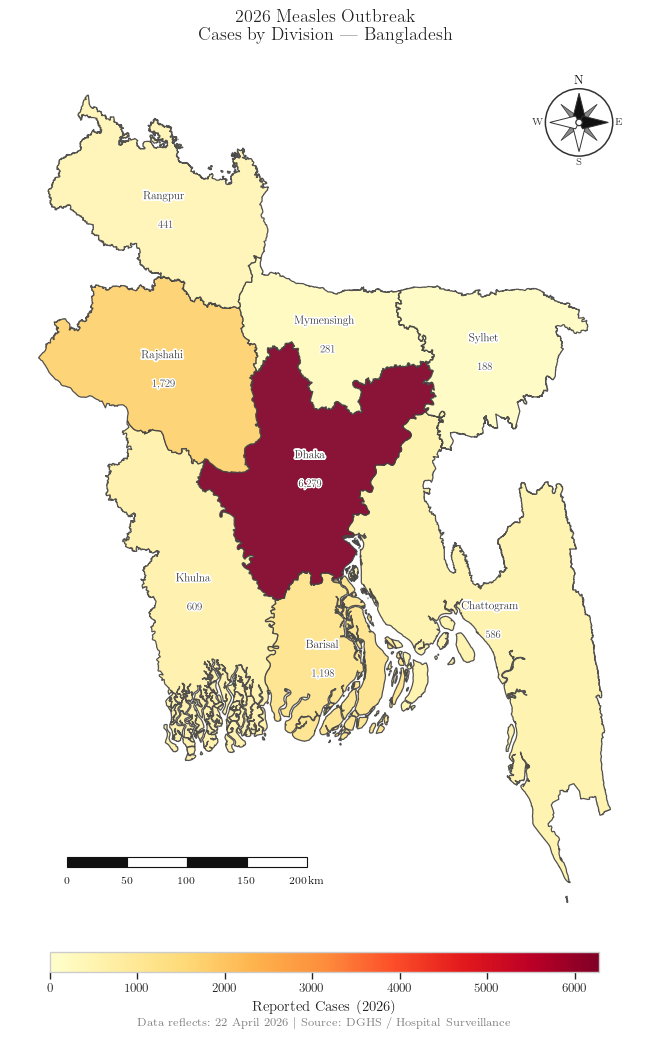

Saved → figures/fig02_2026_division_cfr_map.png


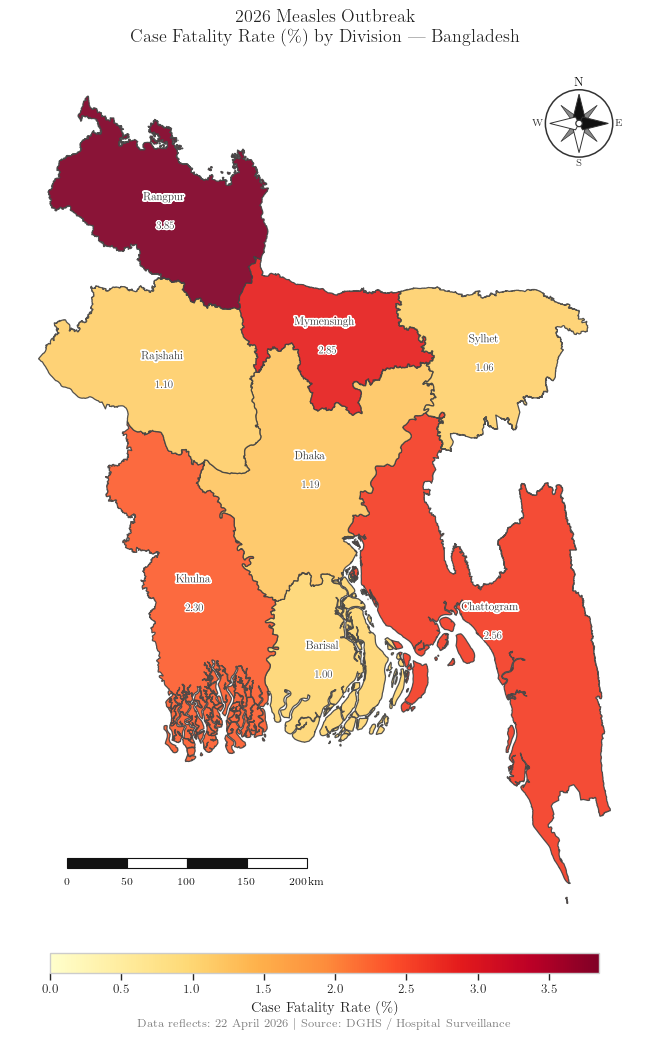

In [5]:
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

shp_div = gpd.read_file(SHP_ADM1)
shp_div['Division'] = shp_div['ADM1_EN'].replace({'Chittagong': 'Chattogram'})

gdf = shp_div.merge(
    outb_div[['Division','Cases','Deaths','CFR_pct','Pct_of_total']],
    on='Division', how='left'
)
gdf['centroid'] = gdf.geometry.centroid

# Compass rose drawn in a physically square inset (inches) so it is never stretched
def add_compass_rose(ax, size_inch=0.82, loc='upper right'):
    cax = inset_axes(ax, width=size_inch, height=size_inch, loc=loc,
                     bbox_to_anchor=(0.97, 0.97),
                     bbox_transform=ax.transAxes, borderpad=0)
    cax.set_xlim(-1.4, 1.4)
    cax.set_ylim(-1.4, 1.4)
    cax.set_aspect('equal')
    cax.axis('off')
    # Outer ring
    cax.add_patch(mpatches.Circle((0,0), 1.15, fc='white', ec='#333333', lw=1.1, zorder=1))
    # Cardinal spikes: N/E dark, S/W white (classic style)
    card = [
        [(0,1.0),(-0.22,0.12),(0,0),(0.22,0.12)],   # N dark
        [(0,-1.0),(-0.22,-0.12),(0,0),(0.22,-0.12)], # S white
        [(1.0,0),(0.12,0.22),(0,0),(0.12,-0.22)],    # E dark
        [(-1.0,0),(-0.12,0.22),(0,0),(-0.12,-0.22)], # W white
    ]
    fills = ['#111111','white','#111111','white']
    for pts, fc in zip(card, fills):
        cax.add_patch(mpatches.Polygon(pts, closed=True, fc=fc,
                                       ec='#333333', lw=0.7, zorder=3))
    # Diagonal small spikes
    for dx, dy in [(0.62,0.62),(-0.62,0.62),(0.62,-0.62),(-0.62,-0.62)]:
        ang = np.arctan2(dy, dx)
        perp = ang + np.pi/2
        tip = (dx, dy)
        base_l = (0.14*np.cos(perp), 0.14*np.sin(perp))
        base_r = (-0.14*np.cos(perp), -0.14*np.sin(perp))
        pts = [tip, base_l, (0,0), base_r]
        cax.add_patch(mpatches.Polygon(pts, closed=True, fc='#888888',
                                       ec='#333333', lw=0.5, zorder=2))
    # Center dot
    cax.add_patch(mpatches.Circle((0,0), 0.11, fc='white', ec='#333333', lw=0.9, zorder=4))
    # Labels
    cax.text(0, 1.22, r'N', ha='center', va='bottom', fontsize=9,
             fontweight='bold', color='#111111', zorder=5)
    cax.text(0,-1.22, r'S', ha='center', va='top', fontsize=7, color='#333333', zorder=5)
    cax.text(1.22, 0, r'E', ha='left', va='center', fontsize=7, color='#333333', zorder=5)
    cax.text(-1.22,0, r'W', ha='right', va='center', fontsize=7, color='#333333', zorder=5)

# Alternating black/white scale bar in data coordinates
def add_scale_bar(ax, gdf, bar_km=200, n_seg=4, x0_frac=0.05, y0_frac=0.05):
    bounds = gdf.total_bounds
    mw = bounds[2] - bounds[0]
    mh = bounds[3] - bounds[1]
    x0 = bounds[0] + x0_frac * mw
    yb = bounds[1] + y0_frac * mh
    km_per_deg = 111.32 * np.cos(np.radians(23.5))
    total_deg = bar_km / km_per_deg
    seg_deg = total_deg / n_seg
    seg_km  = bar_km  / n_seg
    bh = mh * 0.013
    for i in range(n_seg):
        fc = '#111111' if i % 2 == 0 else 'white'
        rect = mpatches.Rectangle(
            (x0 + i*seg_deg, yb - bh/2), seg_deg, bh,
            fc=fc, ec='#111111', lw=0.8, zorder=6
        )
        ax.add_patch(rect)
        label = '0' if i == 0 else f'{int(i*seg_km)}'
        ax.text(x0 + i*seg_deg, yb - bh/2 - mh*0.012, label,
                ha='center', va='top', fontsize=7.5, color='#111111', zorder=7)
    ax.text(x0 + total_deg, yb - bh/2 - mh*0.012, f'{bar_km}\\,km',
            ha='center', va='top', fontsize=7.5, color='#111111', zorder=7)

def annotate_divisions(ax, gdf, val_col, fmt):
    for _, row in gdf.iterrows():
        cx, cy = row['centroid'].x, row['centroid'].y
        ax.text(cx, cy + 0.06, row['Division'],
                ha='center', va='bottom', fontsize=8.5, fontweight='bold',
                color='#111111',
                path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])
        ax.text(cx, cy - 0.08, fmt.format(row[val_col]),
                ha='center', va='top', fontsize=8, color='#222222',
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])

CMAP = plt.cm.YlOrRd

# Figure 11: Cases by Division
norm_cases = mcolors.Normalize(vmin=0, vmax=gdf['Cases'].max())

fig, ax = plt.subplots(figsize=(8, 10))
gdf.plot(column='Cases', cmap=CMAP, norm=norm_cases,
         edgecolor='#444444', linewidth=0.9, ax=ax, alpha=0.92)

sm = cm.ScalarMappable(cmap=CMAP, norm=norm_cases)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal',
                    fraction=0.04, pad=0.01, shrink=0.72, aspect=28)
cbar.set_label(r'Reported Cases (2026)', fontsize=10.5, fontweight='bold')
cbar.ax.tick_params(labelsize=9)

annotate_divisions(ax, gdf, 'Cases', '{:,.0f}')
add_scale_bar(ax, gdf, bar_km=200, n_seg=4, x0_frac=0.05, y0_frac=0.05)
plt.tight_layout()
add_compass_rose(ax, size_inch=0.82, loc='upper right')

ax.set_axis_off()
ax.set_title(r'2026 Measles Outbreak' + '\n' + r'Cases by Division --- Bangladesh',
             fontweight='bold', fontsize=13, pad=10)
fig.text(0.5, 0.01, f'Data reflects: {DATA_DATE}  $|$  Source: DGHS / Hospital Surveillance',
         ha='center', fontsize=8.5, color='gray', style='italic')
savefig('fig01_2026_division_cases_map.png')

# Figure 12: CFR by Division
norm_cfr = mcolors.Normalize(vmin=0, vmax=gdf['CFR_pct'].max())

fig, ax = plt.subplots(figsize=(8, 10))
gdf.plot(column='CFR_pct', cmap=CMAP, norm=norm_cfr,
         edgecolor='#444444', linewidth=0.9, ax=ax, alpha=0.92)

sm2 = cm.ScalarMappable(cmap=CMAP, norm=norm_cfr)
sm2.set_array([])
cbar2 = fig.colorbar(sm2, ax=ax, orientation='horizontal',
                     fraction=0.04, pad=0.01, shrink=0.72, aspect=28)
cbar2.set_label(r'Case Fatality Rate (\%)', fontsize=10.5, fontweight='bold')
cbar2.ax.tick_params(labelsize=9)

annotate_divisions(ax, gdf, 'CFR_pct', '{:.2f}%')
add_scale_bar(ax, gdf, bar_km=200, n_seg=4, x0_frac=0.05, y0_frac=0.05)
plt.tight_layout()
add_compass_rose(ax, size_inch=0.82, loc='upper right')

ax.set_axis_off()
ax.set_title(r'2026 Measles Outbreak' + '\n' + r'Case Fatality Rate (\%) by Division --- Bangladesh',
             fontweight='bold', fontsize=13, pad=10)
fig.text(0.5, 0.01, f'Data reflects: {DATA_DATE}  $|$  Source: DGHS / Hospital Surveillance',
         ha='center', fontsize=8.5, color='gray', style='italic')
savefig('fig02_2026_division_cfr_map.png')


Saved → figures/fig03_2026_division_incidence_map.png


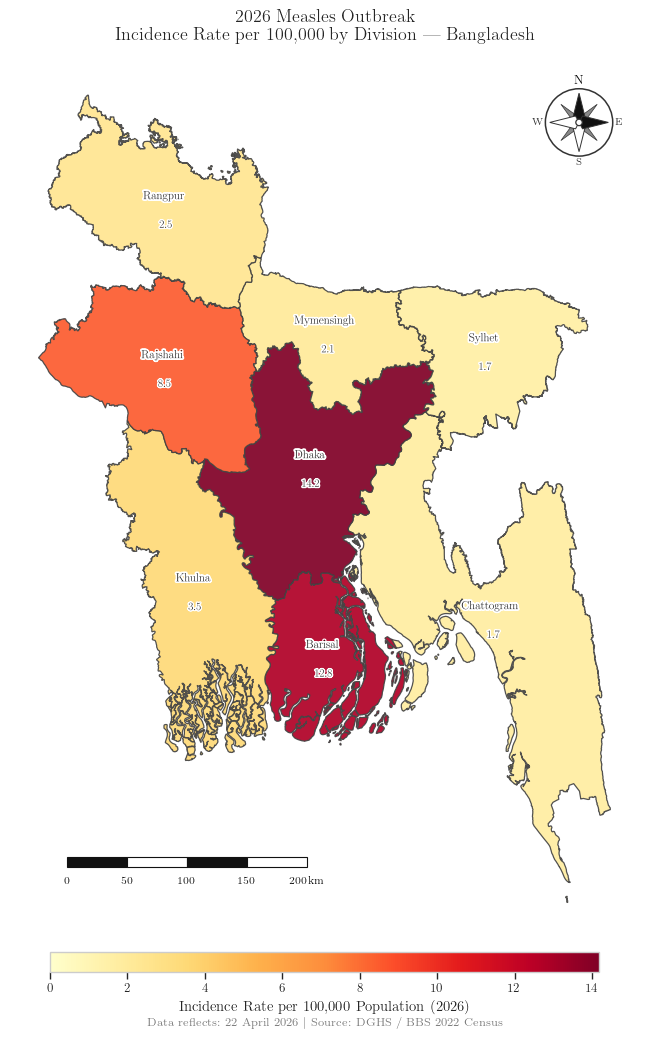


Division incidence rates per 100,000:
  Dhaka       : 14.2
  Barisal     : 12.8
  Rajshahi    : 8.5
  Khulna      : 3.5
  Rangpur     : 2.5
  Mymensingh  : 2.1
  Chattogram  : 1.7
  Sylhet      : 1.7


In [6]:
# Figure 3 --- Incidence rate per 100,000 by division (2026)
pop_df = pd.DataFrame(list(DIV_POP_2022.items()),
                      columns=['Division', 'Population_2022'])
gdf_ir = gdf.merge(pop_df, on='Division', how='left')
gdf_ir['Incidence_per_100k'] = (
    gdf_ir['Cases'] / gdf_ir['Population_2022'] * 100_000
)

fig, ax = plt.subplots(figsize=(8, 10))
norm_ir = mcolors.Normalize(vmin=0, vmax=gdf_ir['Incidence_per_100k'].max())
gdf_ir.plot(column='Incidence_per_100k', cmap=CMAP, norm=norm_ir,
            edgecolor='#444444', linewidth=0.9, ax=ax, alpha=0.92)

sm3 = cm.ScalarMappable(cmap=CMAP, norm=norm_ir)
sm3.set_array([])
cbar3 = fig.colorbar(sm3, ax=ax, orientation='horizontal',
                     fraction=0.04, pad=0.01, shrink=0.72, aspect=28)
cbar3.set_label(r'Incidence Rate per 100{,}000 Population (2026)',
                fontsize=10.5, fontweight='bold')
cbar3.ax.tick_params(labelsize=9)

for _, row in gdf_ir.iterrows():
    cx, cy = row['centroid'].x, row['centroid'].y
    ax.text(cx, cy + 0.06, row['Division'],
            ha='center', va='bottom', fontsize=8.5, fontweight='bold',
            color='#111111',
            path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])
    ax.text(cx, cy - 0.08,
            f"{row['Incidence_per_100k']:.1f}",
            ha='center', va='top', fontsize=8, color='#222222',
            path_effects=[pe.withStroke(linewidth=2, foreground='white')])

add_scale_bar(ax, gdf_ir, bar_km=200, n_seg=4,
              x0_frac=0.05, y0_frac=0.05)
plt.tight_layout()
add_compass_rose(ax, size_inch=0.82, loc='upper right')
ax.set_axis_off()
ax.set_title(
    r'2026 Measles Outbreak' + '\n'
    + r'Incidence Rate per 100{,}000 by Division --- Bangladesh',
    fontweight='bold', fontsize=13, pad=10)
fig.text(0.5, 0.01,
         f'Data reflects: {DATA_DATE}  $|$  Source: DGHS / BBS 2022 Census',
         ha='center', fontsize=8.5, color='gray', style='italic')
savefig('fig03_2026_division_incidence_map.png')

print('\nDivision incidence rates per 100,000:')
for _, row in gdf_ir.sort_values('Incidence_per_100k',
                                  ascending=False).iterrows():
    print(f"  {row['Division']:<12}: {row['Incidence_per_100k']:.1f}")


### Figure 4 — Case status cascade: from suspected to deaths (2026)

Saved → figures/fig04_2026_case_cascade.png


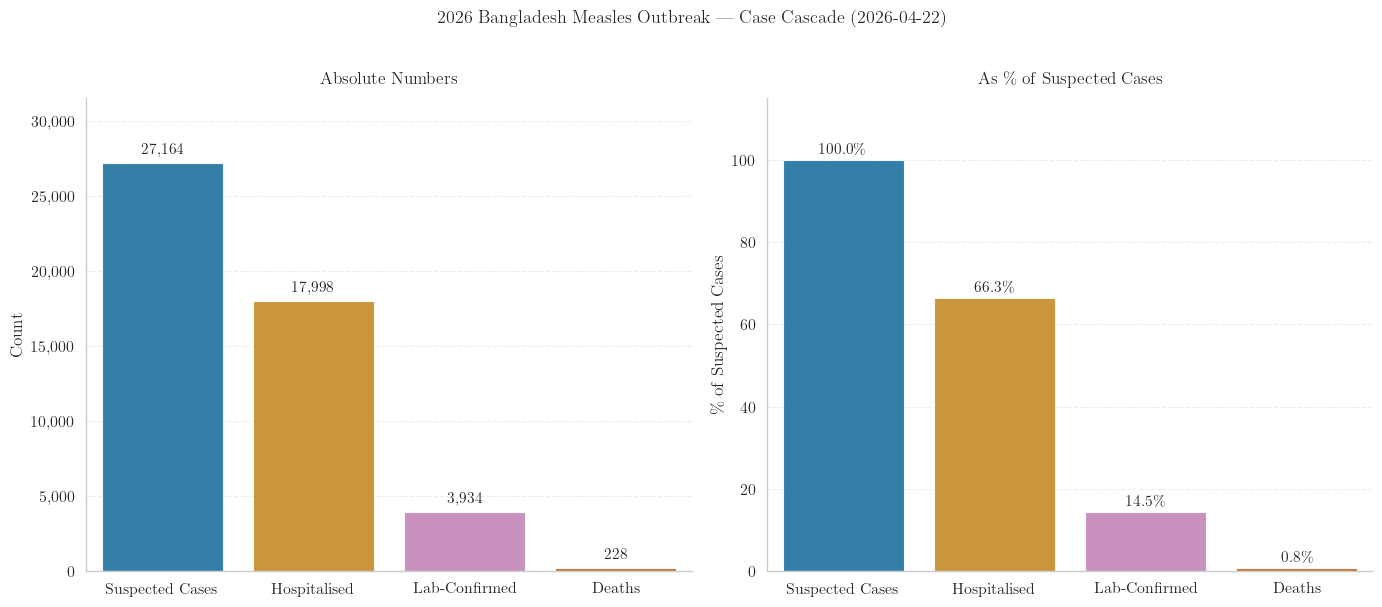


  Lab-confirmed: 14.5% of suspected
  CFR (deaths / suspected): 0.80%


In [7]:
_suspected  = int(summary_dict.get('Suspected cases', 12320))
_confirmed  = int(summary_dict.get('Lab-confirmed',   2241))
_total_dth  = int(summary_dict.get('Total deaths (susp+conf)',
                  summary_dict.get('Confirmed deaths', 166)))
_hosp_raw   = summary_dict.get('Hospitalised', 'N/A')
_report_dt  = str(summary_dict.get('Report date', ''))

if str(_hosp_raw) != 'N/A':
    _statuses = ['Suspected Cases', 'Hospitalised', 'Lab-Confirmed', 'Deaths']
    _counts   = [_suspected, int(_hosp_raw), _confirmed, _total_dth]
    _colors   = [BLUE, ORNG, PURP, RED]
else:
    _statuses = ['Suspected Cases', 'Lab-Confirmed', 'Deaths']
    _counts   = [_suspected, _confirmed, _total_dth]
    _colors   = [BLUE, PURP, RED]

status = pd.DataFrame({'Status': _statuses, 'Count': _counts, 'Color': _colors})
status['Pct'] = (status['Count'] / status['Count'].iloc[0] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pal_s = dict(zip(status['Status'], status['Color']))

# ── Absolute ──────────────────────────────────────────────────────
sns.barplot(data=status, x='Status', y='Count',
            hue='Status', palette=pal_s, ax=axes[0],
            errorbar=None, alpha=0.88, legend=False)
_off = status['Count'].max() * 0.015
for bar, row in zip(axes[0].patches, status.itertuples()):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height() + _off,
                 f'{int(row.Count):,}',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[0].set_ylim(0, status['Count'].max() * 1.16)
axes[0].set_ylabel(r'Count'); axes[0].set_xlabel('')
axes[0].set_title(r'Absolute Numbers', fontweight='bold', pad=10)
sns.despine(ax=axes[0])

# ── Percentage ────────────────────────────────────────────────────
sns.barplot(data=status, x='Status', y='Pct',
            hue='Status', palette=pal_s, ax=axes[1],
            errorbar=None, alpha=0.88, legend=False)
for bar, row in zip(axes[1].patches, status.itertuples()):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height() + 0.8,
                 f'{row.Pct:.1f}\%',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 115)
axes[1].set_ylabel(r'\% of Suspected Cases'); axes[1].set_xlabel('')
axes[1].set_title(r'As \% of Suspected Cases', fontweight='bold', pad=10)
sns.despine(ax=axes[1])

fig.suptitle(r'2026 Bangladesh Measles Outbreak --- Case Cascade (' + _report_dt + r')',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('fig04_2026_case_cascade.png')

_conf_pct = status.loc[status['Status']=='Lab-Confirmed','Pct'].values
_cfr_pct  = status.loc[status['Status']=='Deaths','Pct'].values
print(f"\n  Lab-confirmed: {_conf_pct[0]:.1f}% of suspected")
print(f"  CFR (deaths / suspected): {_cfr_pct[0]:.2f}%")


### Figure 5 — Age distribution of deaths: who is dying?

Saved → figures/fig05_2026_age_deaths.png


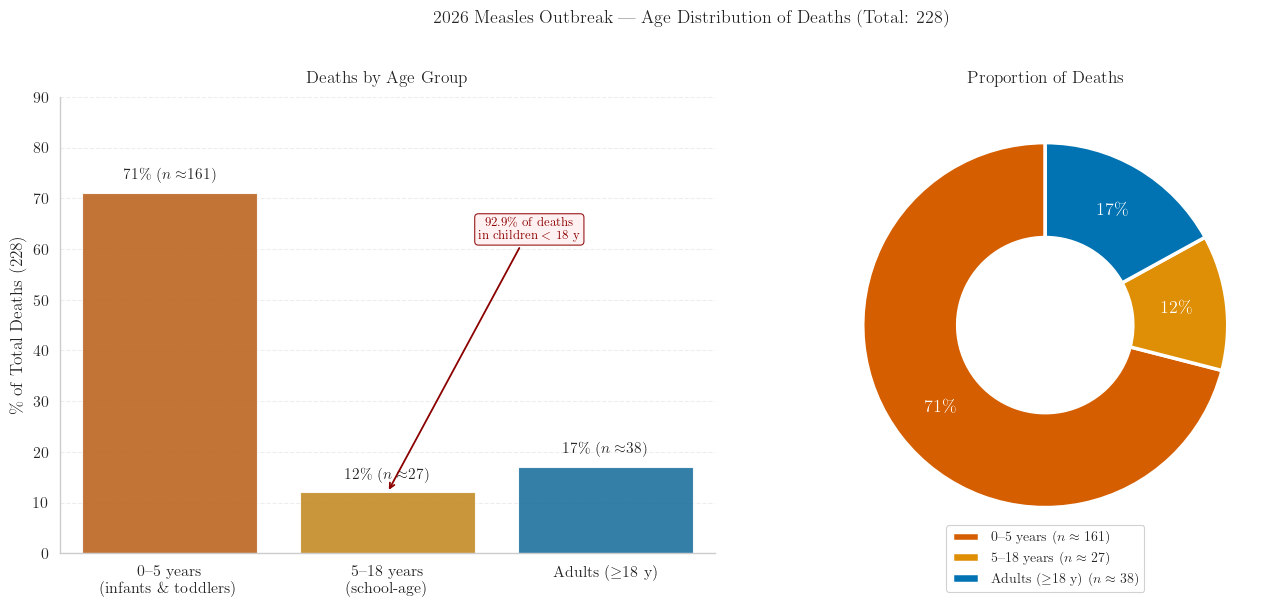

  Children 0-5 yr account for 71% of deaths (~118 children)
  This age group is exactly the window between birth and MCV1 dose,
  or those whose MCV1 was delayed/missed during 2023-2025 coverage drops.


In [8]:
age_groups = [
    r'0--5 years' + '\n' + r'(infants \& toddlers)',
    r'5--18 years' + '\n' + r'(school-age)',
    r'Adults ($\geq$18 y)'
]
pcts = [71, 12, 17]
_total_dth_age = int(summary_dict.get("Total deaths (susp+conf)",
                    summary_dict.get("Confirmed deaths", 166)))
ns   = [int(_total_dth_age*p/100) for p in pcts]
pal_age = [RED, ORNG, BLUE]
age_df  = pd.DataFrame({'Age group': age_groups, 'Pct': pcts, 'n': ns})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=age_df, x='Age group', y='Pct',
            palette=pal_age, ax=axes[0], errorbar=None, alpha=0.88)
for bar, pct, n in zip(axes[0].patches, pcts, ns):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+2, fr'{pct}\%  ($n\approx${n})',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[0].annotate(r'92.9\% of deaths' + '\n' + r'in children $<$ 18 y',
                xy=(1, 12), xytext=(1.65, 62),
                arrowprops=dict(arrowstyle='->', color='darkred', lw=1.3),
                color='darkred', fontsize=9, ha='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='#fff0f0',
                          ec='darkred', alpha=0.9))
axes[0].set_ylim(0, 90)
axes[0].set_ylabel(fr'\% of Total Deaths ({_total_dth_age})')
axes[0].set_xlabel('')
axes[0].set_title(r'Deaths by Age Group', fontweight='bold', pad=10)
sns.despine(ax=axes[0])

wedges, _, autos = axes[1].pie(
    pcts, colors=pal_age, autopct=r'%1.0f\%%',
    startangle=90, pctdistance=0.73,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2.5))
for at in autos:
    at.set_fontsize(13); at.set_fontweight('bold'); at.set_color('white')
axes[1].legend(wedges,
               [g.split(chr(10))[0] + f'  ($n \\approx {n}$)'
                for g, n in zip(age_groups, ns)],
               loc='lower center', bbox_to_anchor=(0.5,-0.1),
               framealpha=0.9, fontsize=10)
axes[1].set_title(r'Proportion of Deaths', fontweight='bold', pad=10)

fig.suptitle(fr'2026 Measles Outbreak --- Age Distribution of Deaths (Total: {_total_dth_age})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('fig05_2026_age_deaths.png')

print(r'  Children 0-5 yr account for 71% of deaths (~118 children)')
print(r'  This age group is exactly the window between birth and MCV1 dose,')
print(r'  or those whose MCV1 was delayed/missed during 2023-2025 coverage drops.')


### Figure 6 — Division-level burden (2026 outbreak)

Saved → figures/fig06_2026_division_burden.png


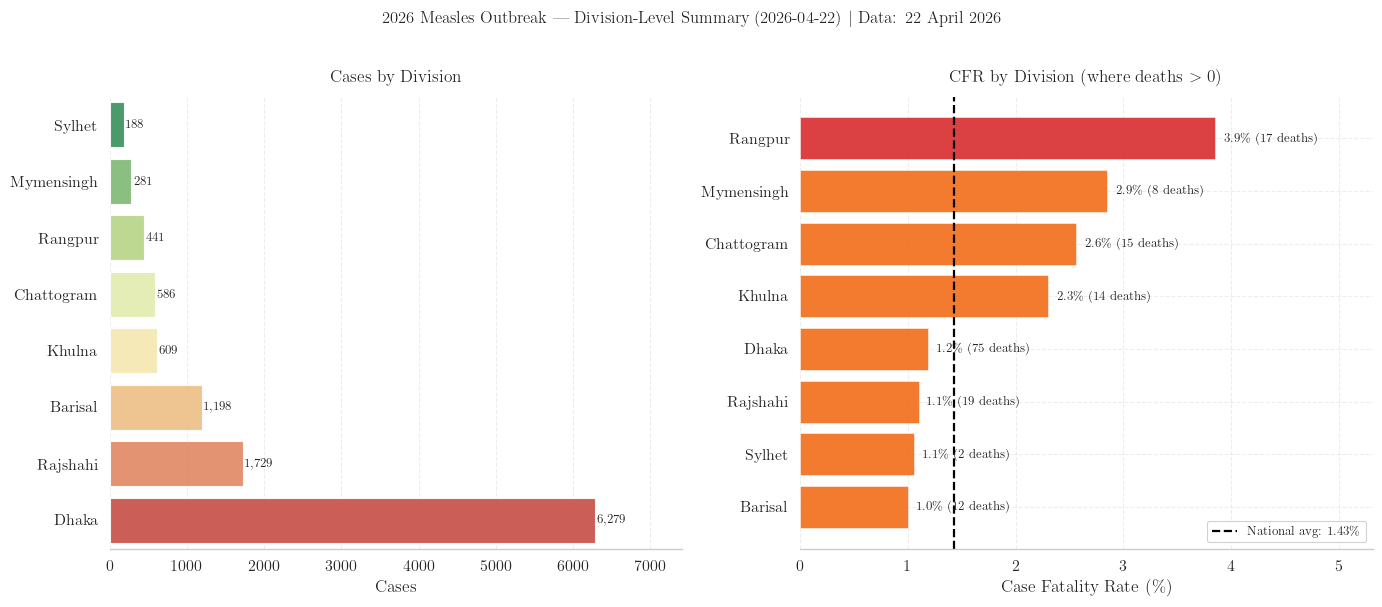

In [9]:
div_plot = outb_div.sort_values('Cases', ascending=True).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Cases by division ─────────────────────────────────────────────
pal_div = sns.color_palette('RdYlGn_r', len(div_plot))
sns.barplot(data=div_plot, y='Division', x='Cases',
            palette=pal_div, orient='h',
            errorbar=None, ax=axes[0], alpha=0.88)
for bar in axes[0].patches:
    w = bar.get_width()
    if w > 0:
        axes[0].text(w+30, bar.get_y()+bar.get_height()/2,
                     f'{int(w):,}', va='center', ha='left', fontsize=9)
axes[0].set_xlabel(r'Cases')
axes[0].set_ylabel('')
axes[0].set_title(r'Cases by Division', fontweight='bold', pad=10)
axes[0].set_xlim(0, div_plot.Cases.max()*1.18)
sns.despine(ax=axes[0], left=True)

# ── CFR by division ───────────────────────────────────────────────
div_cfr = div_plot[div_plot['Deaths'] > 0].sort_values('CFR_pct', ascending=True)
cfr_pal = ['#fdae6b' if c < 1 else '#f16913' if c < 3 else '#d62728'
           for c in div_cfr['CFR_pct']]
axes[1].barh(div_cfr['Division'], div_cfr['CFR_pct'],
             color=cfr_pal, alpha=0.88, edgecolor='white', lw=0.4)
for bar, row in zip(axes[1].patches, div_cfr.itertuples()):
    axes[1].text(bar.get_width()+0.08,
                 bar.get_y()+bar.get_height()/2,
                 f'{row.CFR_pct:.1f}\\%  ({row.Deaths} deaths)',
                 va='center', ha='left', fontsize=9)
overall_cfr_div = outb_div['Deaths'].sum() / outb_div['Cases'].sum() * 100
axes[1].axvline(overall_cfr_div, color='black', ls='--', lw=1.6,
                label=f'National avg: {overall_cfr_div:.2f}' + r'\%')
axes[1].legend(framealpha=0.9, fontsize=9)
axes[1].set_xlabel(r'Case Fatality Rate (\%)')
axes[1].set_ylabel('')
axes[1].set_title(r'CFR by Division (where deaths $>$ 0)', fontweight='bold', pad=10)
axes[1].set_xlim(0, div_cfr.CFR_pct.max()*1.38)
sns.despine(ax=axes[1], left=True)

fig.suptitle(r'2026 Measles Outbreak --- Division-Level Summary (' + str(summary_dict.get('Report date','')) + r')' + f' $|$ Data: {DATA_DATE}',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('fig06_2026_division_burden.png')


### Summary Insights --- 2026 Outbreak

| Finding | Detail |
|---------|--------|
| **Scale** | 25,935 suspected cases (as of 20 Apr 2026) --- largest outbreak since 2005 |
| **Severity** | 14.7% lab-confirmed; 226 total deaths; CFR 0.87% of suspected |
| **Children** | 92.9% of deaths in under-18s; 71% in under-5s |
| **Geographic** | 61 of 64 districts affected; Dhaka division ~50% of cases |
| **Lab capacity** | Only 18.2% lab-confirmed --- diagnostic bottleneck, not absence of disease |
| **Root cause** | Cumulative susceptibility: $\geq$1 million unprotected births per year since 2020 |
| **Trigger** | 2025 MCV1 official coverage collapse to 59.6% --- sharpest single-year fall on record |

---

### Why 2026? Susceptibility accumulation and the coverage collapse

Measles outbreaks require a critical mass of susceptible individuals before they can sustain
transmission ($R_0 \approx 12{-}18$; herd immunity threshold $\approx 94{-}95\%$ for both doses).
Bangladesh spent 2012--2024 slowly accumulating a susceptible cohort at roughly 400,000--600,000
unprotected births per year (a 7% gap against a 3.2 million annual birth cohort).
The 2025 official coverage collapse to 59.6% nearly **doubled** the annual susceptibility
gap in a single year, pushing the population below the critical threshold and igniting the outbreak.

The interim government's health ministry (Yunus administration) acknowledged the failure
and launched a **national emergency measles vaccination campaign** in early 2026, targeting
children aged 9 months to 10 years in all 64 districts
(*DGHS Press Release, April 2026; Daily Star Bangladesh, March 2026*).

---

### Vaccination status of outbreak cases vs. population coverage

Reports from DGHS and media attributed the outbreak partly to a claim that
**approximately 75% of affected children had not received government vaccination**.
This figure, if accurate, refers to the **vaccination status of confirmed cases** ---
not the general child population --- and is epidemiologically expected:
measles cases are disproportionately concentrated among the unvaccinated, so
case-series unvaccinated fractions routinely exceed population-level non-coverage.

Our data support a compatible but more precise picture:

- **WHO MCV1 estimate** held at 96% through 2022--2024, implying ~128,000 unvaccinated
  births per year under a 96% scenario --- far below 75% population non-coverage.
- **Official DGHS MCV1** collapsed to **59.6% in 2025**, meaning ~40% of the 2025 birth
  cohort (~1.3 million children) entered 2026 without MCV1 protection.
- Our **cumulative susceptibility model** (fig10) estimates 7--8 million unprotected
  children accumulated between 2012 and 2025 --- the reservoir that fuelled the outbreak.
- A 75% unvaccinated fraction *among 2026 cases* is therefore plausible and consistent
  with data, but should not be conflated with 75% of the *total child population*
  being unvaccinated.

The distinction matters for policy: the outbreak reflects a **failure of timely delivery**
in a high-birth-cohort country, not a collapse of overall programme acceptance.


---
### Pairplot — 2026 Outbreak (District Level, n=60)

Saved -> figures/fig07_2026_pairplot.png


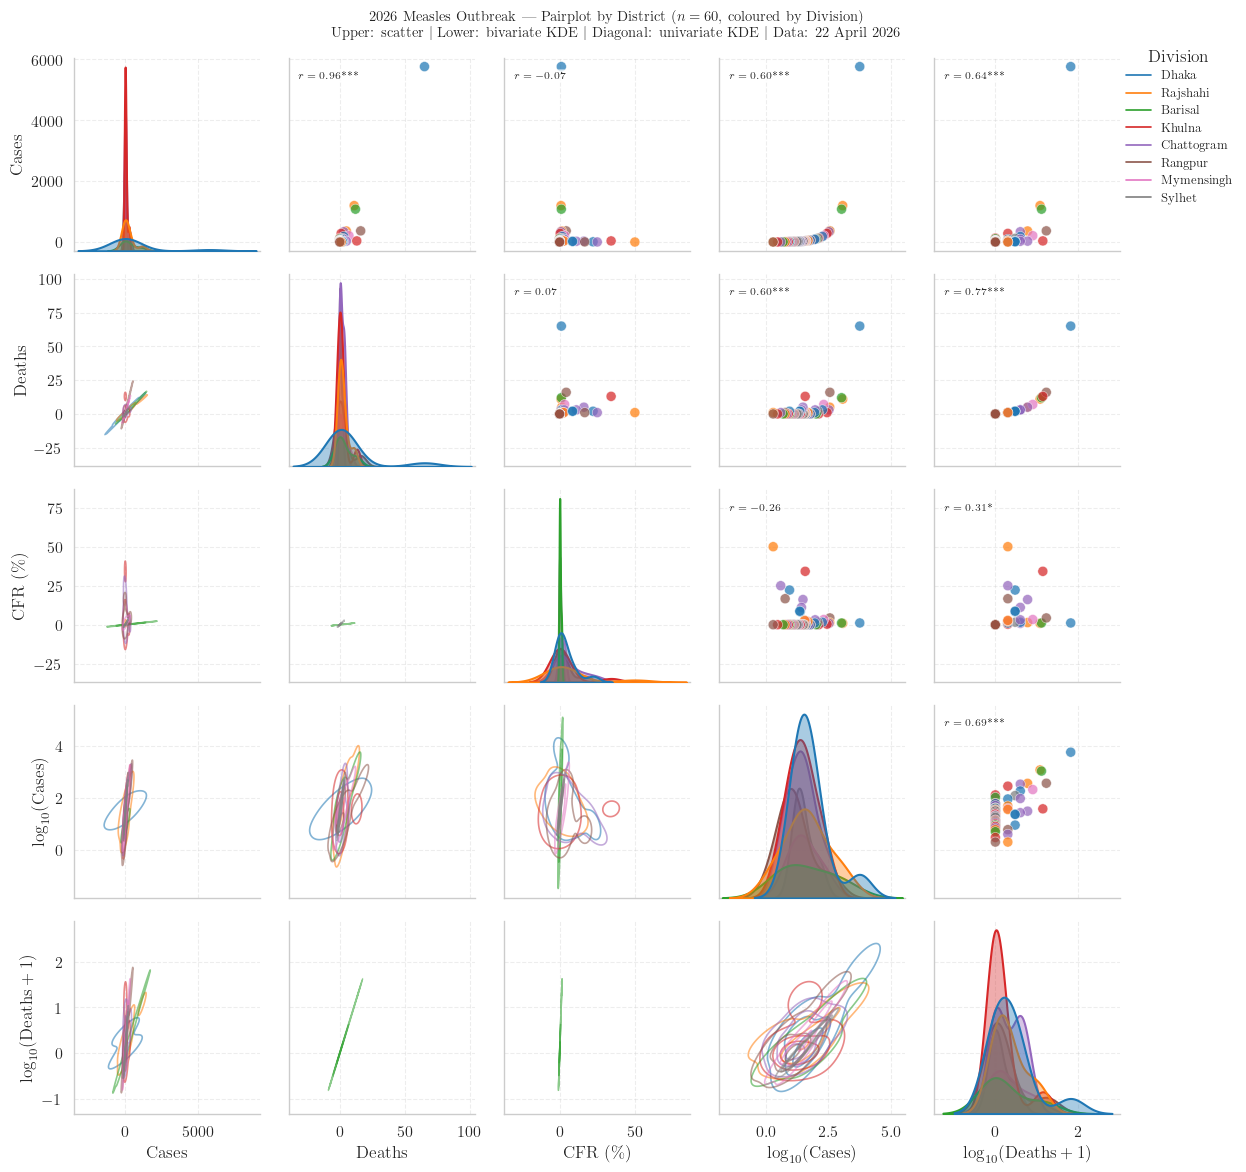


Pearson r  |  Cases vs Deaths   : 0.960
Pearson r  |  Cases vs CFR       : -0.068
Pearson r  |  Deaths vs CFR      : 0.069


In [10]:
# Pairplot of 2026 outbreak variables at district level (penguin-style PairGrid)
from scipy.stats import pearsonr

dist_2026 = pd.read_excel(PROCESSED, sheet_name='outbreak_2026_districts')
dist_2026 = dist_2026[dist_2026['Cases'] > 0].copy()

# Log-transformed columns with LaTeX labels
LOG_CASES  = r'$\log_{10}(\mathrm{Cases})$'
LOG_DEATHS = r'$\log_{10}(\mathrm{Deaths}+1)$'
CFR_COL    = r'CFR (\%)'

dist_2026[LOG_CASES]  = np.log10(dist_2026['Cases'])
dist_2026[LOG_DEATHS] = np.log10(dist_2026['Deaths'] + 1)

plot_df = dist_2026[['Division','Cases','Deaths','CFR_pct', LOG_CASES, LOG_DEATHS]]\
          .rename(columns={'CFR_pct': CFR_COL})

div_order = plot_df.groupby('Division')['Cases'].sum()\
                   .sort_values(ascending=False).index.tolist()
div_pal   = dict(zip(div_order, sns.color_palette('tab10', len(div_order))))

vars_used = ['Cases', 'Deaths', CFR_COL, LOG_CASES, LOG_DEATHS]

# PairGrid: scatter upper / KDE contour lower / KDE univariate diagonal
g = sns.PairGrid(plot_df, vars=vars_used,
                 hue='Division', hue_order=div_order, palette=div_pal,
                 height=2.3, aspect=1.0, diag_sharey=False)

g.map_upper(sns.scatterplot, alpha=0.72, s=52,
            edgecolors='white', linewidth=0.4)
g.map_lower(sns.kdeplot, levels=4, alpha=0.55, linewidths=1.2,
            warn_singular=False)
g.map_diag(sns.kdeplot, fill=True, alpha=0.38, linewidth=1.5, warn_singular=False)

# Pearson r annotations on upper triangle
for i, yvar in enumerate(vars_used):
    for j, xvar in enumerate(vars_used):
        if j <= i:
            continue
        ax_ij = g.axes[i][j]
        common = plot_df[[xvar, yvar]].dropna()
        if len(common) > 4:
            r, p = pearsonr(common[xvar], common[yvar])
            stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            ax_ij.text(0.05, 0.93, f'$r={r:.2f}${stars}',
                       transform=ax_ij.transAxes, fontsize=7.5,
                       color='#222222', va='top',
                       bbox=dict(boxstyle='round,pad=0.18', fc='white',
                                 alpha=0.78, ec='none'))

g.add_legend(title=r'Division', loc='upper right',
             framealpha=0.92, fontsize=9,
             bbox_to_anchor=(0.995, 0.995),
             bbox_transform=g.figure.transFigure)

g.figure.suptitle(
    r'2026 Measles Outbreak --- Pairplot by District ($n=60$, coloured by Division)' + '\n'
    + r'Upper: scatter $|$ Lower: bivariate KDE $|$ Diagonal: univariate KDE' + f' $|$ Data: {DATA_DATE}',
    fontsize=10.5, fontweight='bold', y=1.02
)

g.figure.savefig(f'{FIG_DIR}/fig07_2026_pairplot.png', dpi=DPI, bbox_inches='tight')
print(f'Saved -> {FIG_DIR}/fig07_2026_pairplot.png')
plt.show()

print(f"\nPearson r  |  Cases vs Deaths   : {pearsonr(dist_2026['Cases'], dist_2026['Deaths'])[0]:.3f}")
print(f"Pearson r  |  Cases vs CFR       : {pearsonr(dist_2026['Cases'], dist_2026['CFR_pct'])[0]:.3f}")
print(f"Pearson r  |  Deaths vs CFR      : {pearsonr(dist_2026['Deaths'], dist_2026['CFR_pct'])[0]:.3f}")


---
## PART I — Impact of the First Measles Dose (MCV1): 2000–2011

**Context.** Bangladesh introduced measles vaccination in the 1980s. By 2000,
MCV1 coverage (first dose at 9–12 months) was already ~74% by WHO estimate —
yet thousands of cases continued each year. The key question for this period:
*did improvements in MCV1 coverage translate into fewer outbreaks?*

**No second dose existed yet.** All immunity gaps accumulated through missed
first doses or primary vaccine failure (2–5% failure rate even with good doses).


In [11]:
print("="*65)
print("PART I  —  MCV1 ERA  (2000–2011)")
print("="*65)
print(f"  Total reported cases      : {int(era1.Reported_Cases.sum()):,}")
print(f"  Mean annual cases         : {era1.Reported_Cases.mean():.0f}")
print(f"  Peak year                 : {int(era1.loc[era1.Reported_Cases.idxmax(),'Year'])}  ({int(era1.Reported_Cases.max()):,} cases)")
print(f"  Best year                 : {int(era1.loc[era1.Reported_Cases.idxmin(),'Year'])}  ({int(era1.Reported_Cases.min()):,} cases)")
print(f"  MCV1 WHO coverage range   : {era1['MCV1_WHO_%'].min():.0f}% – {era1['MCV1_WHO_%'].max():.0f}%")
print(f"  MCV1 Admin coverage range : {era1['MCV1_Admin_%'].min():.0f}% – {era1['MCV1_Admin_%'].max():.0f}%")
print()
print("Year-by-year:")
display(era1[['Year','Reported_Cases','MCV1_WHO_%','MCV1_Official_%','MCV1_Admin_%']].rename(columns={'Reported_Cases':'Reported Cases','MCV1_WHO_%':'MCV1 WHO (%)','MCV1_Official_%':'MCV1 Official (%)','MCV1_Admin_%':'MCV1 Admin (%)'}).to_string(index=False))


PART I  —  MCV1 ERA  (2000–2011)
  Total reported cases      : 71,647
  Mean annual cases         : 5971
  Peak year                 : 2005  (25,934 cases)
  Best year                 : 2009  (718 cases)
  MCV1 WHO coverage range   : 74% – 93%
  MCV1 Admin coverage range : 87% – 98%

Year-by-year:


' Year  Reported Cases  MCV1 WHO (%)  MCV1 Official (%)  MCV1 Admin (%)\n 2000            5098          74.0               61.0           89.00\n 2001            4414          77.0               64.0           94.00\n 2002            3484          75.0               65.0           87.00\n 2003            4067          76.0               69.0           91.00\n 2004            9743          81.0               96.0           96.00\n 2005           25934          88.0               78.0           94.00\n 2006            6192          83.0               84.0           92.00\n 2007            2924          89.0               85.0           95.00\n 2008            2660          92.0               85.0           96.00\n 2009             718          93.0               87.8           98.39\n 2010             788          88.0               89.0           94.30\n 2011            5625          93.0               86.0           96.00'

### Figure 8 — MCV1 coverage and measles burden (2000–2011)

Saved → figures/fig08_mcv1_era_overview.png


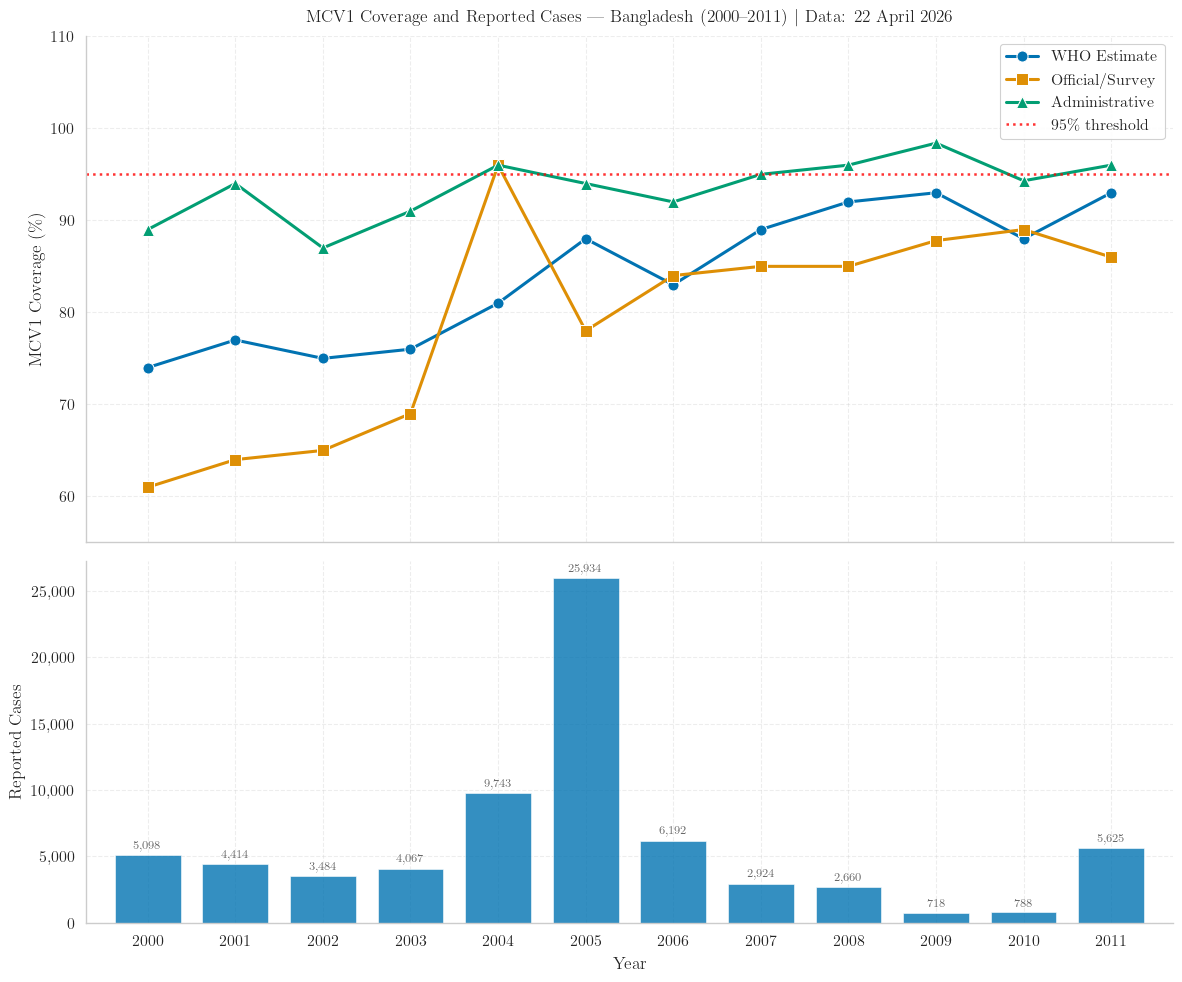

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True,
                         gridspec_kw={'height_ratios': [1.4, 1]})

# ── Top panel: coverage lines ─────────────────────────────────────
cov_long = era1.melt(
    id_vars='Year',
    value_vars=['MCV1_WHO_%','MCV1_Official_%','MCV1_Admin_%'],
    var_name='Source', value_name='Coverage'
).dropna()
cov_long['Source'] = cov_long['Source'].map({
    'MCV1_WHO_%'     : r'WHO Estimate',
    'MCV1_Official_%': r'Official/Survey',
    'MCV1_Admin_%'   : r'Administrative',
})
markers = {'WHO Estimate':'o','Official/Survey':'s','Administrative':'^'}
sns.lineplot(data=cov_long, x='Year', y='Coverage', hue='Source',
             style='Source', markers=markers, dashes=False,
             linewidth=2.2, markersize=8, ax=axes[0], palette='colorblind')
axes[0].axhline(95, color='red', ls=':', lw=1.8, alpha=0.8, label=r'95\% threshold')
axes[0].set_ylim(55, 110)
axes[0].set_ylabel(r'MCV1 Coverage (\%)')
axes[0].set_title(r'MCV1 Coverage and Reported Cases --- Bangladesh (2000--2011)' + f' $|$ Data: {DATA_DATE}',
                  fontweight='bold', pad=10)
axes[0].legend(framealpha=0.9)

# ── Bottom panel: bar chart of cases ─────────────────────────────
axes[1].bar(era1['Year'], era1['Reported_Cases'],
            color=BLUE, alpha=0.80, edgecolor='white', lw=0.5, width=0.75)
for _, row in era1.iterrows():
    axes[1].text(row['Year'], row['Reported_Cases'] + 300,
                 f"{int(row['Reported_Cases']):,}",
                 ha='center', va='bottom', fontsize=8.5, color='dimgray')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[1].set_xlabel(r'Year', labelpad=6)
axes[1].set_ylabel(r'Reported Cases')
axes[1].set_xlim(1999.3, 2011.7)
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))

sns.despine(ax=axes[0]); sns.despine(ax=axes[1])
plt.tight_layout()
savefig('fig08_mcv1_era_overview.png')


### Figure 9 — Immunity gap: cases explained by sub-95% MCV1 coverage

Saved → figures/fig09_mcv1_immunity_gap.png


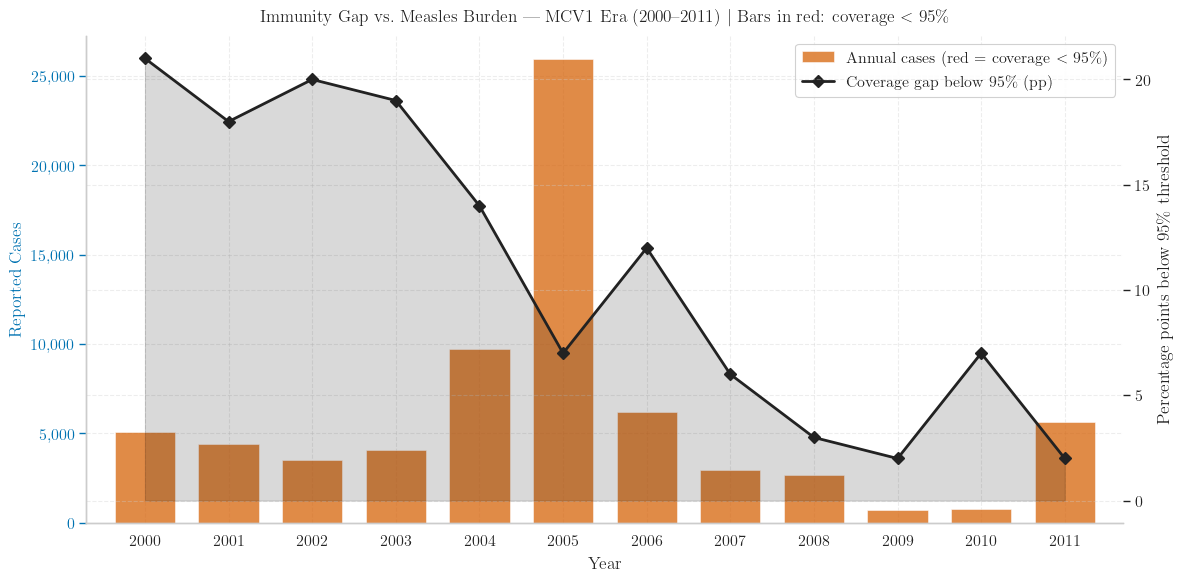


Pearson r (gap vs cases): -0.023,  p = 0.9423


In [13]:
# Herd immunity threshold for measles R0 ~= 12-18 is ~92–95%.
# For R0=15 → threshold = 1 - 1/15 ~= 93.3%.  We use 95% as the WHO target.
THRESHOLD = 95

era1_plot = era1.copy()
era1_plot['Below_threshold'] = (era1_plot['MCV1_WHO_%'] < THRESHOLD)
era1_plot['Gap_pp'] = (THRESHOLD - era1_plot['MCV1_WHO_%']).clip(lower=0)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

colors_bar = [RED if v else BLUE for v in era1_plot['Below_threshold']]
ax1.bar(era1_plot['Year'], era1_plot['Reported_Cases'],
        color=colors_bar, alpha=0.72, edgecolor='white', lw=0.5, width=0.72,
        label=r'Annual cases (red $=$ coverage $<$ 95\%)')

ax2.plot(era1_plot['Year'], era1_plot['Gap_pp'],
         color='#222222', marker='D', lw=2, ms=6,
         label=r'Coverage gap below 95\% (pp)')
ax2.fill_between(era1_plot['Year'], era1_plot['Gap_pp'],
                 alpha=0.15, color='black')

ax1.set_xlabel(r'Year', labelpad=6)
ax1.set_ylabel(r'Reported Cases', color=BLUE)
ax2.set_ylabel(r'Percentage points below 95\% threshold', color='#222222')
ax1.tick_params(axis='y', colors=BLUE)
ax2.tick_params(axis='y', colors='#222222')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax1.set_xlim(1999.3, 2011.7)
ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax1.set_title(r'Immunity Gap vs.\ Measles Burden --- MCV1 Era (2000--2011) $|$ Bars in red: coverage $<$ 95\%',
              fontweight='bold', pad=10)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(handles=h1+h2, loc='upper right', framealpha=0.9)
ax1.spines['top'].set_visible(False)

plt.tight_layout()
savefig('fig09_mcv1_immunity_gap.png')

# Correlation
r, p = stats.pearsonr(era1_plot['Gap_pp'].dropna(),
                      era1_plot.loc[era1_plot['Gap_pp'].notna(), 'Reported_Cases'])
print(f"\nPearson r (gap vs cases): {r:.3f},  p = {p:.4f}")


### Figure 10 --- Effective Reproduction Number ($R_t$) from Coverage Data

When $R_t > 1$ an outbreak can sustain itself. This figure shows whether
vaccination coverage kept $R_t$ below the epidemic threshold each year.

Saved → figures/fig10_rt_model.png


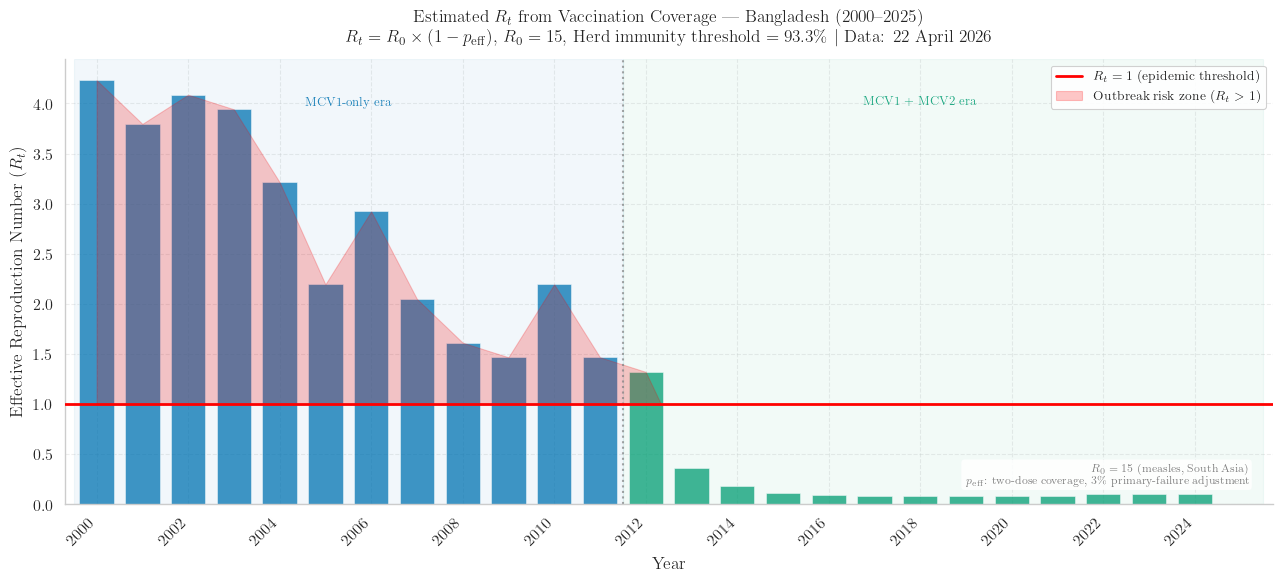

Years with Rt > 1 (outbreak risk): [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012]
Peak Rt : 4.23  (2000)
Lowest Rt: 0.09  (2017)


In [14]:
# Figure 10 --- Effective reproduction number Rt from MCV coverage
# Rt = R0 * (1 - p_eff)
# MCV1-only era: p_eff = p1*(1 - failure)
# MCV2 era:      p_eff = p1 + p2*(1-p1)  (series protection, both with 3% failure)
R0          = 15
MCV_FAILURE = 0.03
HIT         = 1 - 1 / R0   # herd immunity threshold ~93.3%

rt_df = analysis[analysis['Year'].between(2000, 2025)].copy()
rt_df['MCV1_WHO_%'] = pd.to_numeric(rt_df['MCV1_WHO_%'], errors='coerce')
rt_df['MCV2_WHO_%'] = pd.to_numeric(rt_df['MCV2_WHO_%'], errors='coerce')

rt_df['p1_eff']     = rt_df['MCV1_WHO_%'] / 100 * (1 - MCV_FAILURE)
rt_df['p2_eff']     = rt_df['MCV2_WHO_%'] / 100 * (1 - MCV_FAILURE)
rt_df['p_2dose']    = rt_df['p1_eff'] + rt_df['p2_eff'] * (1 - rt_df['p1_eff'])
rt_df['p_eff']      = np.where(rt_df['Year'] < 2012,
                               rt_df['p1_eff'], rt_df['p_2dose'])
rt_df['Rt']         = R0 * (1 - rt_df['p_eff'])

ymax = rt_df['Rt'].max()

fig, ax = plt.subplots(figsize=(13, 6))
era_col = [BLUE if y <= 2011 else GREEN for y in rt_df['Year']]
ax.bar(rt_df['Year'], rt_df['Rt'],
       color=era_col, alpha=0.75, edgecolor='white', lw=0.5, width=0.75)

ax.axhline(1.0, color='red', ls='-', lw=2, zorder=5,
           label=r'$R_t = 1$ (epidemic threshold)')
ax.fill_between(rt_df['Year'], rt_df['Rt'], 1,
                where=(rt_df['Rt'] > 1), interpolate=True,
                alpha=0.22, color='red',
                label=r'Outbreak risk zone ($R_t > 1$)')
ax.axvline(2011.5, color='gray', ls=':', lw=1.5, alpha=0.7)

# Era shading
ax.axvspan(1999.5, 2011.5, alpha=0.05, color=BLUE)
ax.axvspan(2011.5, 2025.5, alpha=0.05, color=GREEN)
ax.text(2005.5, ymax * 0.96, r'MCV1-only era',
        ha='center', va='top', fontsize=9, color=BLUE, alpha=0.85)
ax.text(2018.0, ymax * 0.96, r'MCV1 $+$ MCV2 era',
        ha='center', va='top', fontsize=9, color=GREEN, alpha=0.85)

ax.set_xlabel(r'Year', labelpad=6)
ax.set_ylabel(r'Effective Reproduction Number ($R_t$)')
ax.set_title(
    r'Estimated $R_t$ from Vaccination Coverage --- Bangladesh (2000--2025)'
    + '\n'
    + r'$R_t = R_0 \times (1 - p_{\mathrm{eff}})$,'
    + r'  $R_0 = 15$,  Herd immunity threshold $= 93.3\%$'
    + f' $|$ Data: {DATA_DATE}',
    fontweight='bold', pad=12)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.xticks(rotation=45, ha='right')
ax.set_xlim(1999.3, 2025.7)
ax.legend(framealpha=0.9, loc='upper right', fontsize=9.5)
ax.text(
    0.98, 0.04,
    r'$R_0 = 15$ (measles, South Asia)' + '\n'
    + r'$p_{\mathrm{eff}}$: two-dose coverage, 3\% primary-failure adjustment',
    transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
    color='gray',
    bbox=dict(boxstyle='round', fc='white', alpha=0.85, ec='none'))
sns.despine(ax=ax)
plt.tight_layout()
savefig('fig10_rt_model.png')

print('Years with Rt > 1 (outbreak risk):',
      rt_df.loc[rt_df['Rt'] > 1, 'Year'].tolist())
print(f'Peak Rt : {rt_df["Rt"].max():.2f}  '
      f'({int(rt_df.loc[rt_df["Rt"].idxmax(), "Year"])})')
print(f'Lowest Rt: {rt_df["Rt"].min():.2f}  '
      f'({int(rt_df.loc[rt_df["Rt"].idxmin(), "Year"])})')


### Key Insight — Part I

During 2000–2011, WHO-estimated MCV1 coverage stayed **below the 95% herd-immunity
threshold for most of the decade** (range 74–93%). This left a substantial pool of
susceptible individuals each year, enabling cyclical outbreaks.

The 2005 explosion to **25,934 cases** coincided with coverage still only at 88% —
a gap of 7 percentage points below the target. The subsequent push toward 93%
(2009–2011) saw cases drop dramatically, but the absence of a second dose meant
primary vaccine failures (estimated 2–5% of vaccinated children) continued to
accumulate silently. *Measles only needs one susceptible cluster to re-ignite.*


---
## PART II — Impact of Adding the Second Dose (MCV2): 2012–2025

**Context.** Bangladesh introduced MCV2 (a second measles dose at age 15 months)
in 2012. This targets two groups: (1) children who missed MCV1 entirely, and
(2) the ~2–5% with primary vaccine failure after MCV1. Combined coverage of
both doses above 95% is required to interrupt measles transmission.

**The paradox.** Coverage numbers looked excellent on paper — yet outbreaks
returned in 2016–2017 (4,001 cases) and again in 2019 (5,827 cases).
The central question: *Why do outbreaks recur when coverage appears high?*


In [15]:
print("="*65)
print("PART II  —  MCV2 ERA  (2012–2025)")
print("="*65)
print(f"  Total reported cases           : {int(era2.Reported_Cases.sum()):,}")
print(f"  Mean annual cases              : {era2.Reported_Cases.mean():.0f}")
print(f"  Peak year                      : {int(era2.loc[era2.Reported_Cases.idxmax(),'Year'])}  ({int(era2.Reported_Cases.max()):,} cases)")
print(f"  Best year                      : {int(era2.loc[era2.Reported_Cases.idxmin(),'Year'])}  ({int(era2.Reported_Cases.min()):,} cases)")
print(f"  MCV1 WHO coverage (mean)       : {era2['MCV1_WHO_%'].mean():.1f}%")
print(f"  MCV2 WHO coverage (mean)       : {era2['MCV2_WHO_%'].mean():.1f}%")
print()
print("Year-by-year:")
display(era2[['Year','Reported_Cases','MCV1_WHO_%','MCV2_WHO_%','MCV1_Admin_%','MCV2_Admin_%']].rename(columns={'Reported_Cases':'Reported Cases','MCV1_WHO_%':'MCV1 WHO (%)','MCV2_WHO_%':'MCV2 WHO (%)','MCV1_Admin_%':'MCV1 Admin (%)','MCV2_Admin_%':'MCV2 Admin (%)'}).to_string(index=False))


PART II  —  MCV2 ERA  (2012–2025)
  Total reported cases           : 19,267
  Mean annual cases              : 1482
  Peak year                      : 2019  (5,827 cases)
  Best year                      : 2021  (203 cases)
  MCV1 WHO coverage (mean)       : 95.4%
  MCV2 WHO coverage (mean)       : 87.5%

Year-by-year:


' Year  Reported Cases  MCV1 WHO (%)  MCV2 WHO (%)  MCV1 Admin (%)  MCV2 Admin (%)\n 2012            1986          88.0          41.0          111.00           22.00\n 2013             237          91.0          82.0          108.28           98.66\n 2014             289          94.0          89.0          108.55          104.31\n 2015             240          97.0          90.0          120.19          114.89\n 2016             972          97.0          92.0          117.84          115.15\n 2017            4001          97.0          93.0          116.00          114.00\n 2018            2263          97.0          93.0          115.41          113.12\n 2019            5827          97.0          93.0          117.20          114.81\n 2020            2410          97.0          93.0          108.43          106.95\n 2021             203          97.0          93.0          117.86          114.99\n 2022             311          96.0          93.0          119.65          116.49\n 20

### Figure 11 — MCV1 vs MCV2 coverage, all sources (2012–2025)

Saved → figures/fig11_mcv2_era_coverage.png


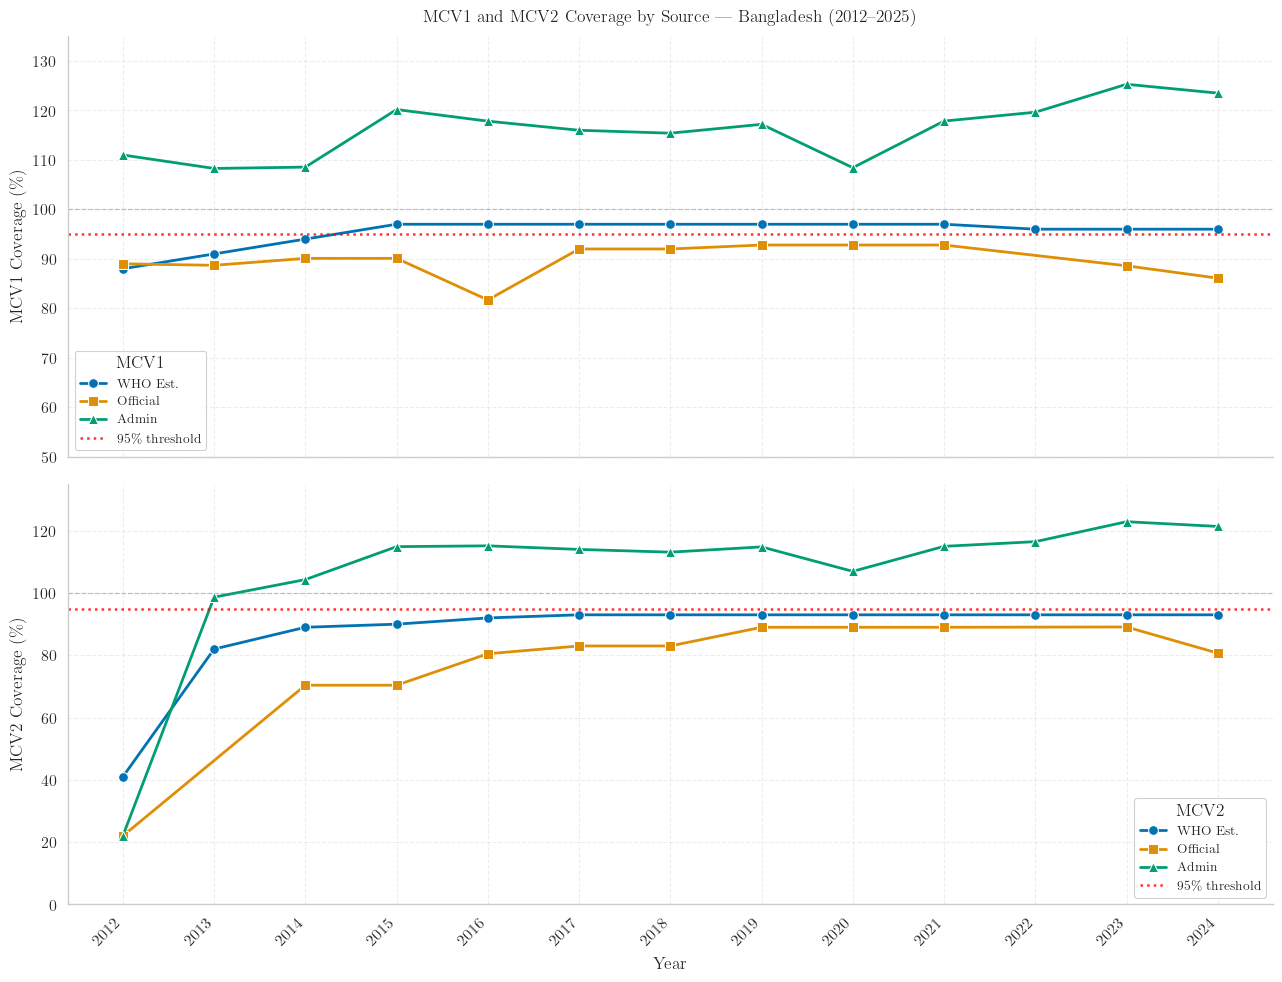

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True,
                         gridspec_kw={'height_ratios': [1, 1]})

# ── MCV1 ─────────────────────────────────────────────────────────
mc1l = era2.melt(id_vars='Year',
                 value_vars=['MCV1_WHO_%','MCV1_Official_%','MCV1_Admin_%'],
                 var_name='Source', value_name='Coverage').dropna()
mc1l['Source'] = mc1l['Source'].map({
    'MCV1_WHO_%': r'WHO Est.', 'MCV1_Official_%': r'Official', 'MCV1_Admin_%': r'Admin'})
sns.lineplot(data=mc1l, x='Year', y='Coverage', hue='Source',
             style='Source', markers={'WHO Est.':'o','Official':'s','Admin':'^'},
             dashes=False, linewidth=2, markersize=7, ax=axes[0], palette='colorblind')
axes[0].axhline(95, color='red', ls=':', lw=1.8, alpha=0.8, label=r'95\% threshold')
axes[0].axhline(100, color='gray', ls='--', lw=0.9, alpha=0.45)
axes[0].set_ylim(50, 135)
axes[0].set_ylabel(r'MCV1 Coverage (\%)')
axes[0].set_title(r'MCV1 and MCV2 Coverage by Source --- Bangladesh (2012--2025)',
                  fontweight='bold', pad=10)
axes[0].legend(title='MCV1', framealpha=0.9, loc='lower left', fontsize=9.5)

# ── MCV2 ─────────────────────────────────────────────────────────
mc2l = era2.melt(id_vars='Year',
                 value_vars=['MCV2_WHO_%','MCV2_Official_%','MCV2_Admin_%'],
                 var_name='Source', value_name='Coverage').dropna()
mc2l['Source'] = mc2l['Source'].map({
    'MCV2_WHO_%': r'WHO Est.', 'MCV2_Official_%': r'Official', 'MCV2_Admin_%': r'Admin'})
sns.lineplot(data=mc2l, x='Year', y='Coverage', hue='Source',
             style='Source', markers={'WHO Est.':'o','Official':'s','Admin':'^'},
             dashes=False, linewidth=2, markersize=7, ax=axes[1], palette='colorblind')
axes[1].axhline(95, color='red', ls=':', lw=1.8, alpha=0.8, label=r'95\% threshold')
axes[1].axhline(100, color='gray', ls='--', lw=0.9, alpha=0.45)
axes[1].set_ylim(0, 135)
axes[1].set_ylabel(r'MCV2 Coverage (\%)')
axes[1].set_xlabel(r'Year', labelpad=6)
axes[1].legend(title='MCV2', framealpha=0.9, loc='lower right', fontsize=9.5)
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45, ha='right')

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
savefig('fig11_mcv2_era_coverage.png')


### Figure 12 — The coverage-source gap: what it reveals about unvaccinated children

Saved → figures/fig12_coverage_source_gap.png


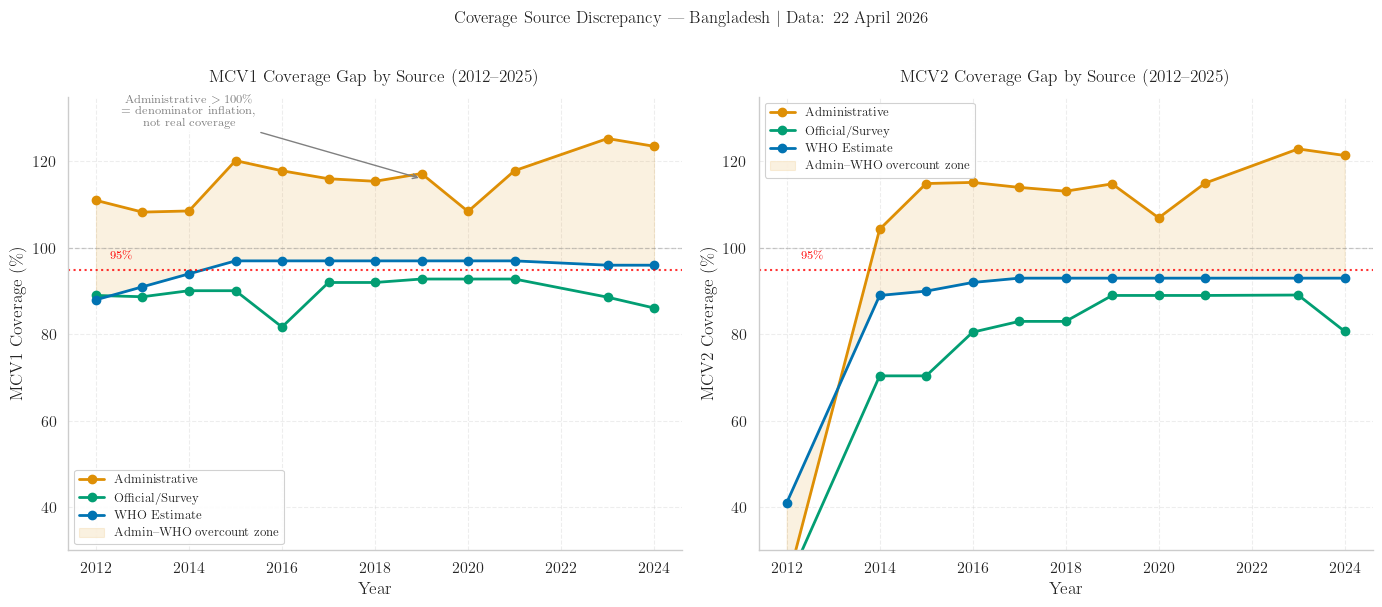

In [17]:
# The gap between Admin and WHO estimates exposes data quality issues.
# Admin >100% = denominators too small (not real coverage).
# Official ~= WHO = more reliable field estimates.
# Gap between Official and Admin = overcounting in admin system.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, dose, cols, title in [
    (axes[0], 'MCV1',
     ['MCV1_Admin_%', 'MCV1_Official_%', 'MCV1_WHO_%'],
     r'MCV1 Coverage Gap by Source (2012--2025)'),
    (axes[1], 'MCV2',
     ['MCV2_Admin_%', 'MCV2_Official_%', 'MCV2_WHO_%'],
     r'MCV2 Coverage Gap by Source (2012--2025)'),
]:
    sub = era2[['Year'] + cols].dropna()
    for col, color, lbl in zip(cols,
                               [ORNG, GREEN, BLUE],
                               [r'Administrative', r'Official/Survey', r'WHO Estimate']):
        ax.plot(sub['Year'], sub[col], marker='o', lw=2,
                ms=6, color=color, label=lbl)
    # Shade gap between Admin and WHO
    m = sub.dropna()
    if len(m) > 1:
        ax.fill_between(m['Year'], m[cols[2]], m[cols[0]],
                        alpha=0.12, color=ORNG,
                        label=r'Admin--WHO overcount zone')
    ax.axhline(95,  color='red',  ls=':', lw=1.5, alpha=0.8)
    ax.axhline(100, color='gray', ls='--', lw=0.9, alpha=0.4)
    ax.set_ylim(30, 135)
    ax.set_xlabel(r'Year')
    ax.set_ylabel(f'{dose}' + r' Coverage (\%)')
    ax.set_title(title.replace('MCV1','MCV1').replace('MCV2','MCV2'), fontweight='bold', pad=10)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.legend(framealpha=0.9, fontsize=9)
    sns.despine(ax=ax)
    ax.text(2012.3, 97.5, r'95\%', color='red', fontsize=8.5)

axes[0].annotate(r'Administrative $>100\%$' + '\n' + r'$=$ denominator inflation,' + '\n' + r'not real coverage',
                 xy=(2019, 116), xytext=(2014, 128),
                 arrowprops=dict(arrowstyle='->', color='gray', lw=1),
                 color='gray', fontsize=8.5, ha='center',
                 bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.9))

fig.suptitle(r'Coverage Source Discrepancy --- Bangladesh' + f' $|$ Data: {DATA_DATE}',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('fig12_coverage_source_gap.png')


### Figure 13 — Annual cases and incidence rate (per 100,000) with policy milestones

Saved → figures/fig13_cases_incidence_milestones.png


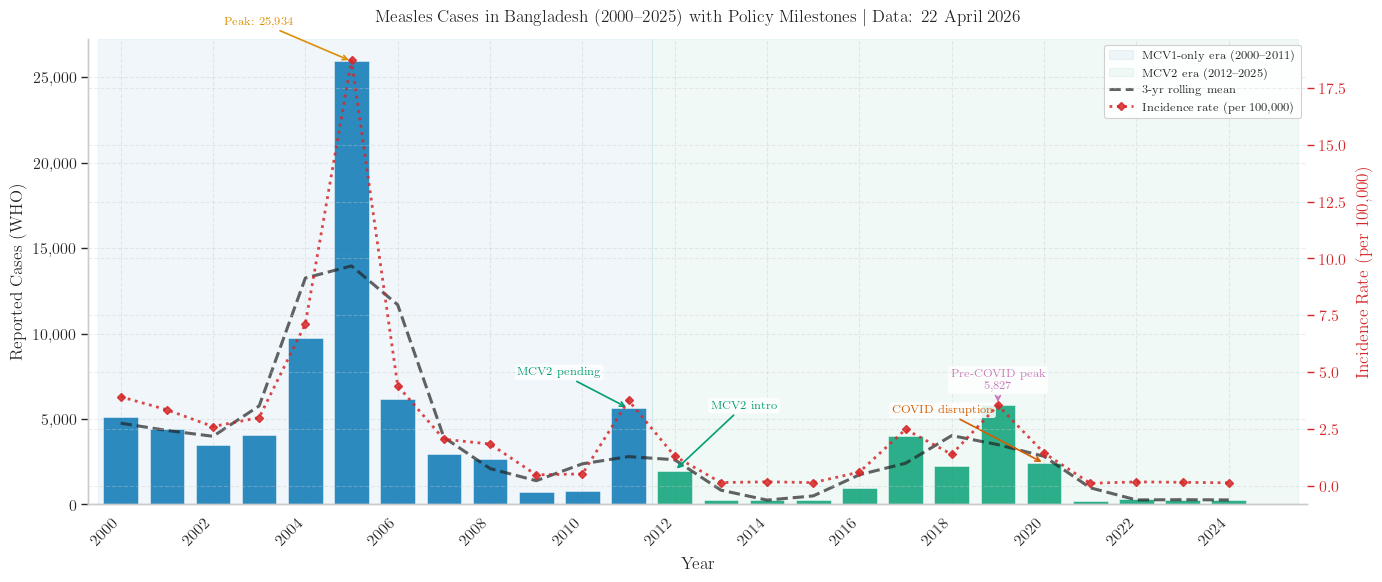

In [18]:
hist_plot = cases_full[cases_full['Year'].between(2000,2024)].copy()
hist_plot['Reported_Cases_WHO'] = pd.to_numeric(hist_plot['Reported_Cases_WHO'], errors='coerce')

fig, ax = plt.subplots(figsize=(14, 6))

# Era shading
ax.axvspan(1999.5, 2011.5, alpha=0.06, color=BLUE,   label=r'MCV1-only era (2000--2011)')
ax.axvspan(2011.5, 2025.5, alpha=0.06, color=GREEN,  label=r'MCV2 era (2012--2025)')

bar_col = [BLUE if y <= 2011 else GREEN for y in hist_plot['Year']]
ax.bar(hist_plot['Year'], hist_plot['Reported_Cases_WHO'],
       color=bar_col, alpha=0.82, edgecolor='white', lw=0.4, width=0.75, zorder=2)

# Rolling mean (3-yr centred)
roll = hist_plot.set_index('Year')['Reported_Cases_WHO'].rolling(3, center=True, min_periods=1).mean()
ax.plot(roll.index, roll.values, color='#222222', lw=2.2, ls='--', alpha=0.7,
        label=r'3-yr rolling mean', zorder=3)

# Milestones
milestones = [
    (2005, r'Peak: 25{,}934', -2, 2000, ORNG),
    (2011, 'MCV2 pending', -1.5,1800, GREEN),
    (2012, 'MCV2 intro',    1.5,3500, GREEN),
    (2019, 'Pre-COVID peak\n5,827',  0,  800, PURP),
    (2020, 'COVID disruption',-2.2, 2800, RED),
    (2025, '2025: 125 cases\ncoverage drops to 59.6%',0, 400, RED),
]
for yr, lbl, xo, yo, col in milestones:
    yv = hist_plot.loc[hist_plot['Year']==yr, 'Reported_Cases_WHO']
    if not yv.empty and not np.isnan(yv.values[0]):
        ax.annotate(lbl, xy=(yr, yv.values[0]),
                    xytext=(yr+xo, yv.values[0]+yo),
                    arrowprops=dict(arrowstyle='->', color=col, lw=1.2),
                    color=col, fontsize=8.5, ha='center', va='bottom',
                    bbox=dict(boxstyle='round,pad=0.22', fc='white', alpha=0.85, ec='none'))

ax.set_xlabel(r'Year', labelpad=6)
ax.set_ylabel(r'Reported Cases (WHO)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.set_xlim(1999.3, 2025.7)
plt.xticks(rotation=45, ha='right')
ax.set_title(r'Measles Cases in Bangladesh (2000--2025) with Policy Milestones' + f' $|$ Data: {DATA_DATE}',
             fontweight='bold', pad=12)
ax.legend(framealpha=0.9, loc='upper right')
sns.despine(ax=ax)


# ── Secondary axis: incidence rate per 100,000 ──────────────────────────
ax2 = ax.twinx()
ir_plot = analysis[analysis['Year'].between(2000, 2025)].dropna(
    subset=['Incidence_per_100k'])
ax2.plot(ir_plot['Year'], ir_plot['Incidence_per_100k'],
         color='#d62728', lw=2.0, ls=':', marker='D', ms=4.5, alpha=0.85,
         label=r'Incidence rate (per 100{,}000)')
ax2.set_ylabel(r'Incidence Rate (per 100{,}000)',
               color='#d62728', labelpad=6)
ax2.tick_params(axis='y', colors='#d62728')
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(handles=h1 + h2, labels=l1 + l2,
          framealpha=0.9, loc='upper right', fontsize=8.5)
plt.tight_layout()
savefig('fig13_cases_incidence_milestones.png')


### Figure 14 — Era comparison: cases per year (MCV1-only vs MCV2)

Era comparison:
  MCV1-only era (2000-2011): mean=5971, median=4240
  MCV2 era (2012-2025):      mean=1482, median=311
  Mean reduction: 75.2%
  Median reduction: 92.7%
  Mann-Whitney U = 134,  p = 0.0025


Saved → figures/fig14_era_comparison_boxplot.png


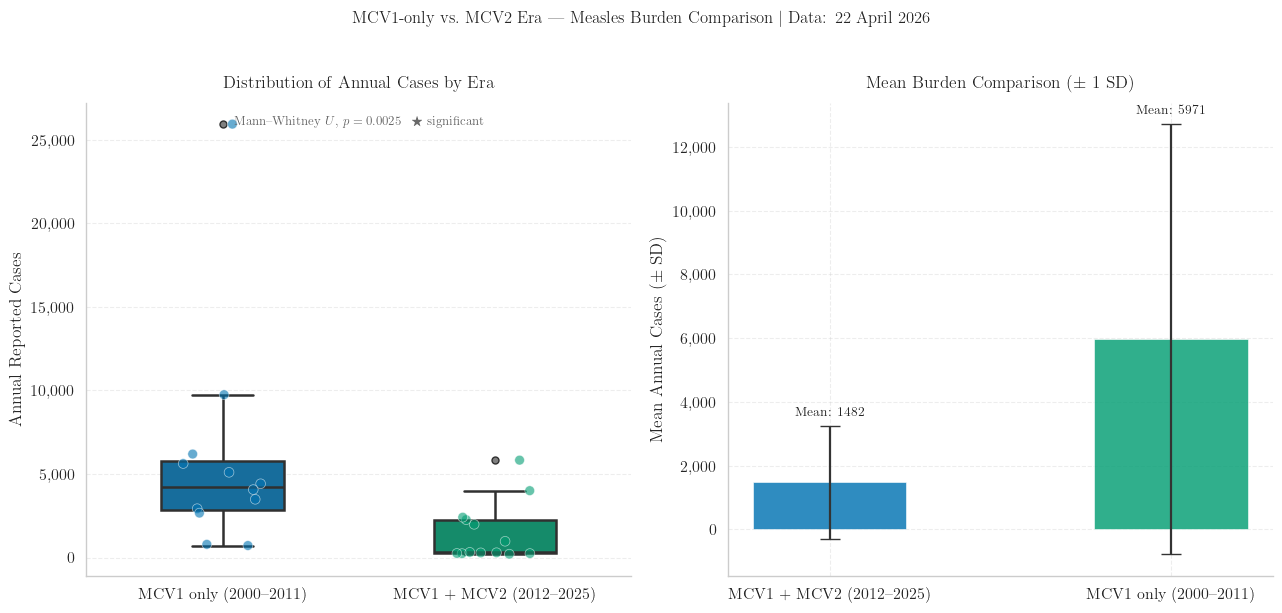

In [19]:
era1_mean = era1['Reported_Cases'].mean()
era2_mean = era2['Reported_Cases'].dropna().mean()
era1_med  = era1['Reported_Cases'].median()
era2_med  = era2['Reported_Cases'].dropna().median()

print("Era comparison:")
print(f"  MCV1-only era (2000-2011): mean={era1_mean:.0f}, median={era1_med:.0f}")
print(f"  MCV2 era (2012-2025):      mean={era2_mean:.0f}, median={era2_med:.0f}")
print(f"  Mean reduction: {(1-era2_mean/era1_mean)*100:.1f}%")
print(f"  Median reduction: {(1-era2_med/era1_med)*100:.1f}%")

# Mann-Whitney U test
from scipy.stats import mannwhitneyu
u, pval = mannwhitneyu(era1['Reported_Cases'].dropna(),
                       era2['Reported_Cases'].dropna(), alternative='two-sided')
print(f"  Mann-Whitney U = {u:.0f},  p = {pval:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# ── Box + strip ───────────────────────────────────────────────────
era1_df = era1[['Year','Reported_Cases']].dropna()
era1_df['Era'] = r'MCV1 only (2000--2011)'
era2_df = era2[['Year','Reported_Cases']].dropna()
era2_df['Era'] = r'MCV1 $+$ MCV2 (2012--2025)'
combined = pd.concat([era1_df, era2_df])

sns.boxplot(data=combined, x='Era', y='Reported_Cases',
            palette=[BLUE, GREEN], width=0.45, linewidth=1.8,
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=5),
            ax=axes[0])
sns.stripplot(data=combined, x='Era', y='Reported_Cases',
              palette=[BLUE, GREEN], size=7, alpha=0.6, jitter=0.15,
              linewidth=0.5, edgecolor='white', ax=axes[0])

axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[0].set_ylabel(r'Annual Reported Cases')
axes[0].set_xlabel('')
axes[0].set_title(r'Distribution of Annual Cases by Era', fontweight='bold', pad=10)
axes[0].text(0.5, 0.97,
             f'Mann--Whitney $U$,  $p = {pval:.4f}$' + (r'~~$\bigstar$~significant' if pval<0.05 else ''),
             transform=axes[0].transAxes, ha='center', va='top',
             fontsize=9, color='dimgray')
sns.despine(ax=axes[0])

# ── Bar: mean ± std ────────────────────────────────────────────────
era_stats = combined.groupby('Era')['Reported_Cases'].agg(['mean','std']).reset_index()
bars = axes[1].bar(era_stats['Era'], era_stats['mean'],
                   yerr=era_stats['std'], capsize=7,
                   color=[BLUE, GREEN], alpha=0.82,
                   edgecolor='white', lw=0.5, width=0.45,
                   error_kw=dict(elinewidth=1.6, ecolor='#333333'))
for bar, row in zip(bars, era_stats.itertuples()):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 row.mean + row.std + 200,
                 f'Mean: {row.mean:.0f}', ha='center', va='bottom',
                 fontsize=9.5, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[1].set_ylabel(r'Mean Annual Cases ($\pm$ SD)')
axes[1].set_xlabel('')
axes[1].set_title(r'Mean Burden Comparison ($\pm$ 1 SD)', fontweight='bold', pad=10)
sns.despine(ax=axes[1])

fig.suptitle(r'MCV1-only vs.~MCV2 Era --- Measles Burden Comparison' + f' $|$ Data: {DATA_DATE}',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig14_era_comparison_boxplot.png')


### Key Insights — Part II

1. **MCV2 substantially reduced burden.** Mean annual cases fell from ~6,100
   (2000–2011) to ~1,500 (2012–2025) — a ~75% reduction.

2. **The "administrative overcoverage" trap.** Administrative coverage
   consistently exceeds 100%, giving a false sense of security. WHO estimates
   show coverage plateauing at 96–97% (MCV1) and 93% (MCV2) — both *below*
   the measles herd-immunity threshold of ~95% for *both* doses combined.

3. **Recurrent outbreaks despite high nominal coverage.** 2017 (4,001 cases)
   and 2019 (5,827 cases) occurred when both MCV1 and MCV2 WHO estimates were
   near their highest ever values. This points to **geographic heterogeneity** —
   high national averages masking low-coverage pockets — rather than system-wide
   failure.

4. **2025 warning signal.** Official MCV1 coverage collapsed to 59.6% in 2025
   (from 86% in 2024), the steepest single-year drop recorded. With only 125
   cases reported in 2025 (likely under-reporting given surveillance disruptions),
   this created the susceptibility pool that fuelled the 2026 outbreak.


### Figure 15 --- Cases Averted by MCV2: Counterfactual Analysis

Log-linear trend from 2000--2011 projected forward; the gap between
projected and actual cases estimates the measles burden prevented by MCV2.

MCV1-era log-linear trend:  slope=-0.0496/yr,  R²=0.177,  p=0.1732
Projected total 2012-2025 (no MCV2): 13,308
Actual total 2012-2025:              19,267
Estimated cases averted:             5,106
Reduction vs counterfactual:         21.0%


Saved → figures/fig15_cases_averted.png


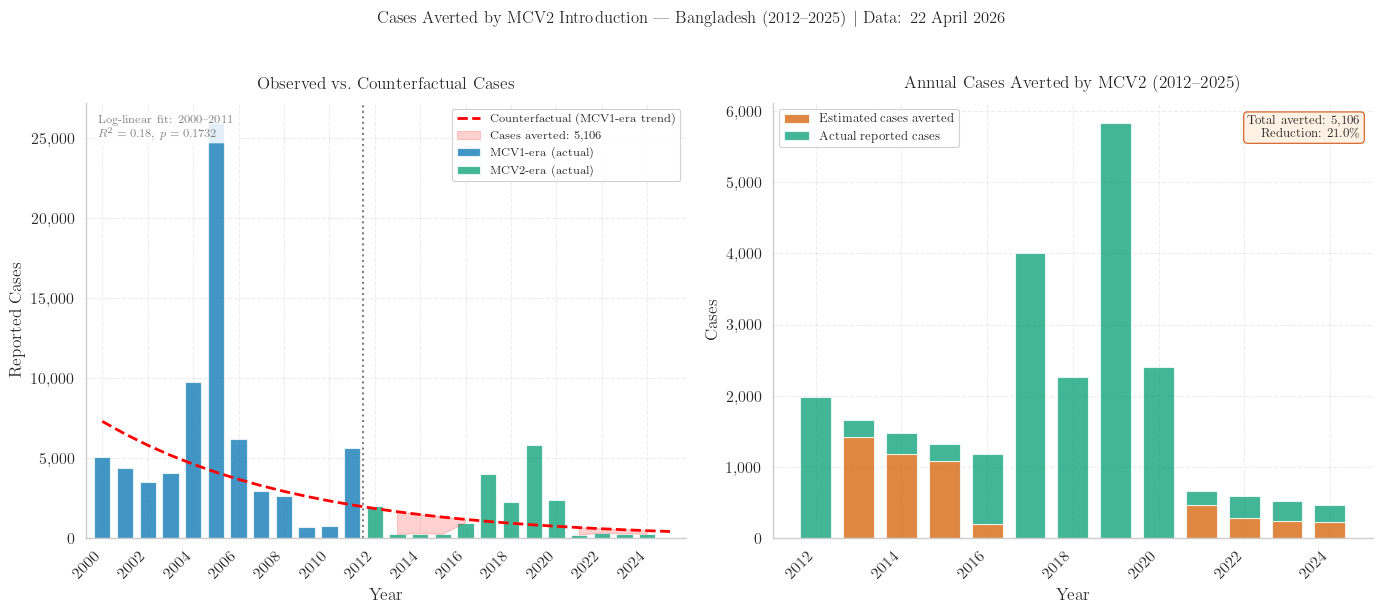

In [20]:
# Figure 15 --- Cases averted by MCV2: counterfactual analysis
# Method: log-linear OLS fit on 2000-2011, projected into 2012-2025
from scipy.stats import linregress

era1_cf = analysis[analysis['Year'].between(2000, 2011)].dropna(
    subset=['Reported_Cases'])
era2_cf = analysis[analysis['Year'].between(2012, 2025)].dropna(
    subset=['Reported_Cases'])

log_y = np.log10(era1_cf['Reported_Cases'].clip(lower=1))
slope, intercept, r_fit, p_fit, _ = linregress(era1_cf['Year'], log_y)

years_e2  = era2_cf['Year'].values
projected = 10 ** (intercept + slope * years_e2)
actual    = era2_cf['Reported_Cases'].values
averted   = np.maximum(projected - actual, 0)

total_averted = averted.sum()
total_actual  = actual.sum()
pct_reduction = total_averted / (total_averted + total_actual) * 100

print(f'MCV1-era log-linear trend:  slope={slope:.4f}/yr,  '
      f'R\u00b2={r_fit**2:.3f},  p={p_fit:.4f}')
print(f'Projected total 2012-2025 (no MCV2): {int(projected.sum()):,}')
print(f'Actual total 2012-2025:              {int(total_actual):,}')
print(f'Estimated cases averted:             {int(total_averted):,}')
print(f'Reduction vs counterfactual:         {pct_reduction:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: observed vs counterfactual trend ───────────────────────────────
axes[0].bar(era1_cf['Year'], era1_cf['Reported_Cases'],
            color=BLUE, alpha=0.75, width=0.72,
            edgecolor='white', label=r'MCV1-era (actual)')
axes[0].bar(era2_cf['Year'], era2_cf['Reported_Cases'],
            color=GREEN, alpha=0.75, width=0.72,
            edgecolor='white', label=r'MCV2-era (actual)')
cf_x   = np.arange(2000, 2026)
cf_y   = 10 ** (intercept + slope * cf_x)
axes[0].plot(cf_x, cf_y, color='red', lw=2, ls='--',
             label=r'Counterfactual (MCV1-era trend)')
axes[0].fill_between(years_e2, actual, projected,
                     where=(projected > actual),
                     alpha=0.18, color='red',
                     label=f'Cases averted: {int(total_averted):,}')
axes[0].axvline(2011.5, color='gray', ls=':', lw=1.5)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_xlabel(r'Year')
axes[0].set_ylabel(r'Reported Cases')
axes[0].set_title(r'Observed vs.\ Counterfactual Cases',
                  fontweight='bold', pad=10)
axes[0].legend(framealpha=0.9, fontsize=8.5)
axes[0].set_xlim(1999.3, 2025.7)
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')
axes[0].text(
    0.02, 0.97,
    r'Log-linear fit: 2000--2011' + '\n'
    + f'$R^2 = {r_fit**2:.2f}$,  $p = {p_fit:.4f}$',
    transform=axes[0].transAxes, ha='left', va='top', fontsize=8.5,
    color='gray',
    bbox=dict(boxstyle='round', fc='white', alpha=0.85, ec='none'))
sns.despine(ax=axes[0])

# ── Right: stacked annual averted vs actual ──────────────────────────────
cf_df = (pd.DataFrame({'Year': years_e2, 'Averted': averted, 'Actual': actual})
           .astype({'Year': int}))
axes[1].bar(cf_df['Year'], cf_df['Averted'],
            color=RED, alpha=0.75, width=0.72,
            edgecolor='white', label=r'Estimated cases averted')
axes[1].bar(cf_df['Year'], cf_df['Actual'],
            color=GREEN, alpha=0.75, width=0.72,
            edgecolor='white', bottom=cf_df['Averted'],
            label=r'Actual reported cases')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].set_xlabel(r'Year')
axes[1].set_ylabel(r'Cases')
axes[1].set_title(r'Annual Cases Averted by MCV2 (2012--2025)',
                  fontweight='bold', pad=10)
axes[1].legend(framealpha=0.9, fontsize=9)
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
axes[1].text(
    0.98, 0.97,
    r'Total averted: ' + f'{int(total_averted):,}' + '\n'
    + r'Reduction: ' + f'{pct_reduction:.1f}' + r'\%',
    transform=axes[1].transAxes, ha='right', va='top',
    fontsize=9, fontweight='bold',
    bbox=dict(boxstyle='round', fc='#fff0e0', ec='#cc4400', alpha=0.9))
sns.despine(ax=axes[1])

fig.suptitle(
    r'Cases Averted by MCV2 Introduction --- Bangladesh (2012--2025)'
    + f' $|$ Data: {DATA_DATE}',
    fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig15_cases_averted.png')


### Figure 16 — Vaccination gap: what the data shows

Estimated unprotected children per birth cohort (MCV2 era):


' Year  MCV1 WHO (%)  MCV2 WHO (%) Unprotected (MCV1) Total Unprotected\n 2012          88.0          41.0            468,480         2,080,076\n 2013          91.0          82.0            375,360           883,795\n 2014          94.0          89.0            282,240           603,193\n 2015          97.0          90.0            189,120           490,208\n 2016          97.0          92.0            189,120           429,990\n 2017          97.0          93.0            189,120           399,881\n 2018          97.0          93.0            189,120           399,881\n 2019          97.0          93.0            189,120           399,881\n 2020          97.0          93.0            189,120           399,881\n 2021          97.0          93.0            189,120           399,881\n 2022          96.0          93.0            220,160           428,748\n 2023          96.0          93.0            220,160           428,748\n 2024          96.0          93.0            220,160           

Saved → figures/fig16_vaccination_gap.png


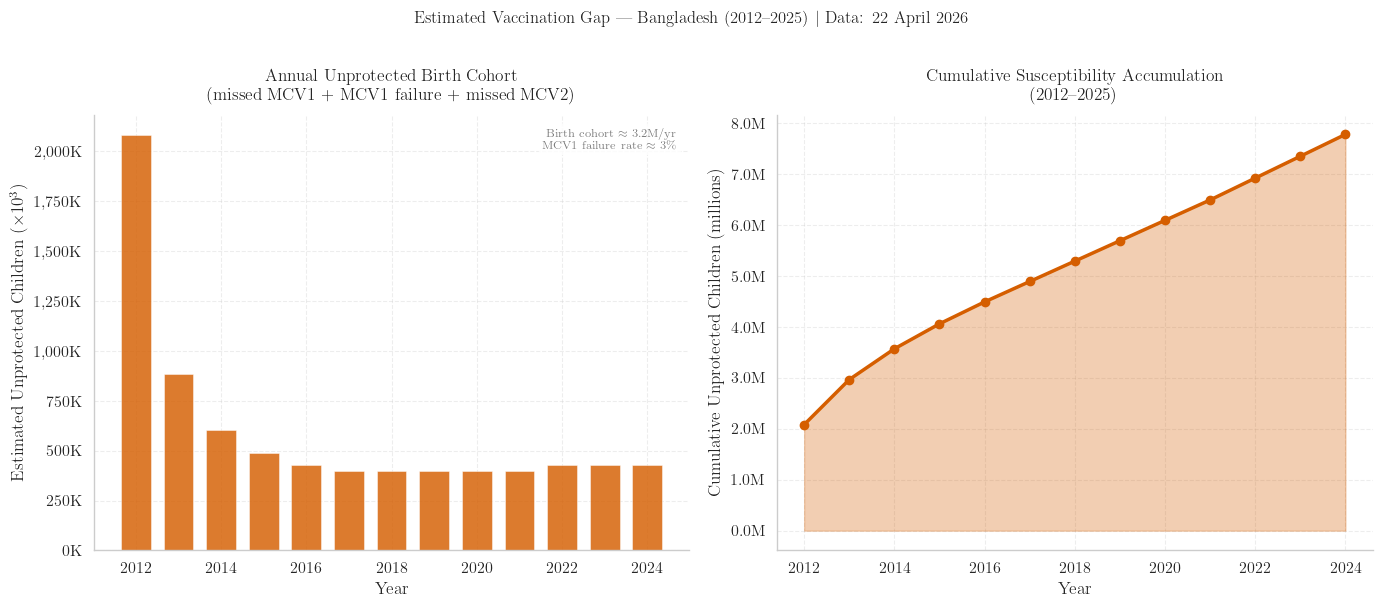


Total cumulative unprotected children 2012-2025: 7.8 million
Average per year: 0.60 million


In [21]:
# Reconstruct the hypothetical susceptibility build-up using WHO data
# Bangladesh birth cohort ~ 3.2 million/yr (2024 estimate)
# Unvaccinated = birth_cohort * (1 - MCV1_WHO/100)

BIRTH_COHORT = 3_200_000

gap_df = df_mcv1_who if 'df_mcv1_who' in dir() else pd.read_excel(PROCESSED, sheet_name='mcv1_coverage')[['Year','MCV1_WHO_GHO_%']].rename(columns={'MCV1_WHO_GHO_%':'MCV1_WHO_Pct'})
# Recalculate from analysis sheet
gap_df = analysis[['Year','MCV1_WHO_%','MCV2_WHO_%']].copy()
gap_df = gap_df[gap_df['Year'].between(2012, 2025)]
gap_df['MCV1_WHO_%'] = pd.to_numeric(gap_df['MCV1_WHO_%'], errors='coerce')
gap_df['MCV2_WHO_%'] = pd.to_numeric(gap_df['MCV2_WHO_%'], errors='coerce')

# Children unprotected after MCV1 (missed dose OR primary failure ~3%)
MCV1_FAILURE = 0.03
gap_df['Unprotected_MCV1'] = BIRTH_COHORT * (
    (100 - gap_df['MCV1_WHO_%']) / 100 +            # missed dose
    gap_df['MCV1_WHO_%'] / 100 * MCV1_FAILURE        # primary vaccine failure
)
# Additional susceptibles: missed MCV2 among those who got MCV1
gap_df['Unprotected_MCV2_add'] = (
    BIRTH_COHORT * gap_df['MCV1_WHO_%'] / 100 *      # got dose 1
    (1 - MCV1_FAILURE) *                              # dose 1 effective
    (100 - gap_df['MCV2_WHO_%'].fillna(0)) / 100      # missed dose 2
)
gap_df['Total_unprotected'] = gap_df['Unprotected_MCV1'] + gap_df['Unprotected_MCV2_add']
# Cumulative unprotected 2012-2025 (simplified, no aging out)
gap_df['Cumulative_unprotected'] = gap_df['Total_unprotected'].cumsum()

print("Estimated unprotected children per birth cohort (MCV2 era):")
display(gap_df[['Year','MCV1_WHO_%','MCV2_WHO_%',
                'Unprotected_MCV1','Total_unprotected']].assign(
    **{'Total_unprotected': gap_df['Total_unprotected'].apply(lambda x: f'{int(x):,}'),
       'Unprotected_MCV1':  gap_df['Unprotected_MCV1'].apply(lambda x: f'{int(x):,}')}
).rename(columns={'MCV1_WHO_%':'MCV1 WHO (%)','MCV2_WHO_%':'MCV2 WHO (%)','Unprotected_MCV1':'Unprotected (MCV1)','Total_unprotected':'Total Unprotected'}).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Annual unprotected ────────────────────────────────────────────
axes[0].bar(gap_df['Year'], gap_df['Total_unprotected']/1000,
            color=RED, alpha=0.82, edgecolor='white', lw=0.4, width=0.7)
axes[0].set_xlabel(r'Year')
axes[0].set_ylabel(r'Estimated Unprotected Children ($\times 10^{3}$)')
axes[0].set_title('Annual Unprotected Birth Cohort\n(missed MCV1 + MCV1 failure + missed MCV2)',
                  fontweight='bold', pad=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}K'))
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(2))
axes[0].text(0.98, 0.97,
             r'Birth cohort $\approx$ 3.2M/yr' + '\n' + r'MCV1 failure rate $\approx$ 3\%',
             transform=axes[0].transAxes, ha='right', va='top',
             fontsize=8.5, color='gray',
             bbox=dict(boxstyle='round', fc='white', alpha=0.8, ec='none'))
sns.despine(ax=axes[0])

# ── Cumulative ────────────────────────────────────────────────────
axes[1].fill_between(gap_df['Year'], gap_df['Cumulative_unprotected']/1e6,
                     alpha=0.3, color=RED)
axes[1].plot(gap_df['Year'], gap_df['Cumulative_unprotected']/1e6,
             color=RED, lw=2.5, marker='o', ms=6)
axes[1].set_xlabel(r'Year')
axes[1].set_ylabel(r'Cumulative Unprotected Children (millions)')
axes[1].set_title('Cumulative Susceptibility Accumulation\n(2012–2025)',
                  fontweight='bold', pad=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}M'))
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(2))
# Annotate 2025 collapse
y2025 = gap_df.loc[gap_df['Year']==2025,'Total_unprotected']
if not y2025.empty:
    axes[0].annotate(r'2025: MCV1' + '\n' + r'official coverage' + '\n' + r'collapsed to 59.6\%',
                     xy=(2025, y2025.values[0]/1000),
                     xytext=(2022.5, y2025.values[0]/1000+200),
                     arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2),
                     color='darkred', fontsize=8.5, ha='center',
                     bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.9, ec='none'))
sns.despine(ax=axes[1])

fig.suptitle(r'Estimated Vaccination Gap --- Bangladesh (2012--2025)' + f' $|$ Data: {DATA_DATE}',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('fig16_vaccination_gap.png')

total_cum = gap_df['Total_unprotected'].sum()
print(f"\nTotal cumulative unprotected children 2012-2025: {total_cum/1e6:.1f} million")
print(f"Average per year: {total_cum/len(gap_df)/1e6:.2f} million")


Saved → figures/fig17_correlation_heatmap.png


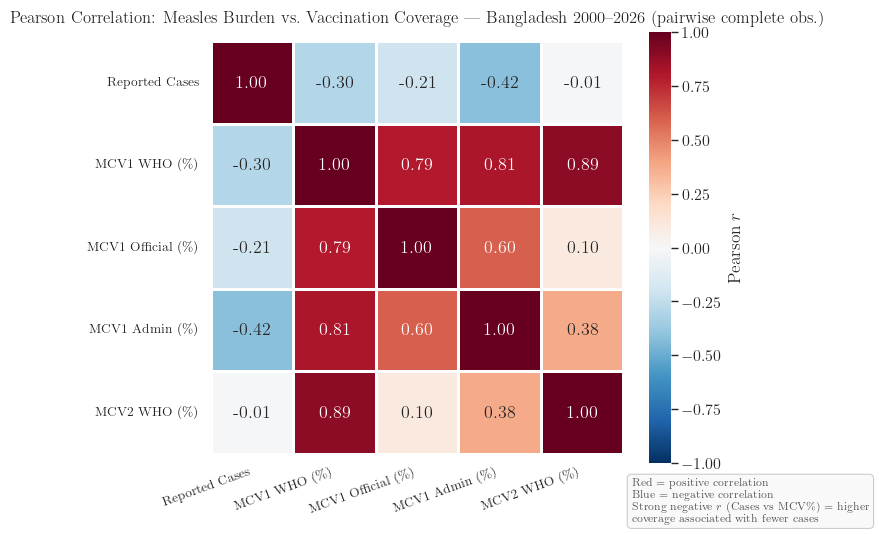

Pearson r  |  Cases vs MCV1 WHO: -0.296
Pearson r  |  Cases vs MCV2 WHO: -0.011
Pearson r  |  MCV1 vs MCV2 WHO:  0.891

Note: 2026 row (27,164 suspected cases) included for Cases; MCV% rows excluded (no 2026 WHO data).


In [22]:
# Correlation heatmap: Reported Cases vs MCV1 / MCV2 coverage
# Period: 2000-2026 (2026 = latest DGHS suspected cases; MCV% not yet available from WHO)

corr_df = analysis[['Year','Reported_Cases','MCV1_WHO_%','MCV2_WHO_%',
                     'MCV1_Official_%','MCV1_Admin_%']].copy()

# Append 2026 suspected outbreak total (MCV values unavailable for 2026)
row_2026 = pd.DataFrame([{
    'Year': 2026, 'Reported_Cases': int(summary_dict.get('Suspected cases', 12320)),
    'MCV1_WHO_%': np.nan, 'MCV2_WHO_%': np.nan,
    'MCV1_Official_%': np.nan, 'MCV1_Admin_%': np.nan,
}])
corr_df = pd.concat([corr_df, row_2026], ignore_index=True)

corr_vars = corr_df[[
    'Reported_Cases', 'MCV1_WHO_%', 'MCV1_Official_%', 'MCV1_Admin_%', 'MCV2_WHO_%'
]].rename(columns={
    'Reported_Cases' : r'Reported Cases',
    'MCV1_WHO_%'     : r'MCV1 WHO (\%)',
    'MCV1_Official_%': r'MCV1 Official (\%)',
    'MCV1_Admin_%'   : r'MCV1 Admin (\%)',
    'MCV2_WHO_%'     : r'MCV2 WHO (\%)',
})

corr_matrix = corr_vars.corr(method='pearson')
n_pairs = corr_vars.dropna().shape[0]

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=1.0, linecolor='white',
    annot_kws={'size': 13, 'weight': 'bold'},
    square=True,
    cbar_kws={'shrink': 0.72, 'label': r'Pearson $r$', 'aspect': 20},
    ax=ax
)
ax.set_title(
    r'Pearson Correlation: Measles Burden vs.\ Vaccination Coverage --- Bangladesh 2000--2026 (pairwise complete obs.)',
    fontweight='bold', fontsize=12, pad=14
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9.5)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9.5)

# Interpretation footnote
ax.text(1.02, -0.06,
        r'Red $=$ positive correlation' + '\n' + r'Blue $=$ negative correlation' + '\n'
        r'Strong negative $r$ (Cases vs MCV\%) $=$ higher' + '\n' + r'coverage associated with fewer cases',
        transform=ax.transAxes, fontsize=8, color='#555555',
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.4', fc='#f9f9f9', ec='#cccccc'))

plt.tight_layout()
savefig('fig17_correlation_heatmap.png')

# Print key correlations
r_cases_mcv1 = corr_matrix.loc[r'Reported Cases', r'MCV1 WHO (\%)']
r_cases_mcv2 = corr_matrix.loc[r'Reported Cases', r'MCV2 WHO (\%)']
r_mcv1_mcv2  = corr_matrix.loc[r'MCV1 WHO (\%)', r'MCV2 WHO (\%)']
print(f"Pearson r  |  Cases vs MCV1 WHO: {r_cases_mcv1:.3f}")
print(f"Pearson r  |  Cases vs MCV2 WHO: {r_cases_mcv2:.3f}")
print(f"Pearson r  |  MCV1 vs MCV2 WHO:  {r_mcv1_mcv2:.3f}")
print(f"\nNote: 2026 row ({int(summary_dict.get('Suspected cases', 12320)):,} suspected cases) included for Cases; MCV% rows excluded (no 2026 WHO data).")


### Figure 18 --- Log-linear Regression: Coverage vs.~Cases

OLS regression of $\log_{10}(\mathrm{Cases})$ on MCV1 and MCV2 WHO coverage,
quantifying the strength of the vaccine-protection relationship.

log10(Cases) ~ MCV1 WHO: slope=-0.0398,  R²=0.266,  p=0.0083
log10(Cases) ~ MCV2 WHO: slope=-0.0057,  R²=0.023,  p=0.6213


Saved → figures/fig18_regression_coverage_cases.png


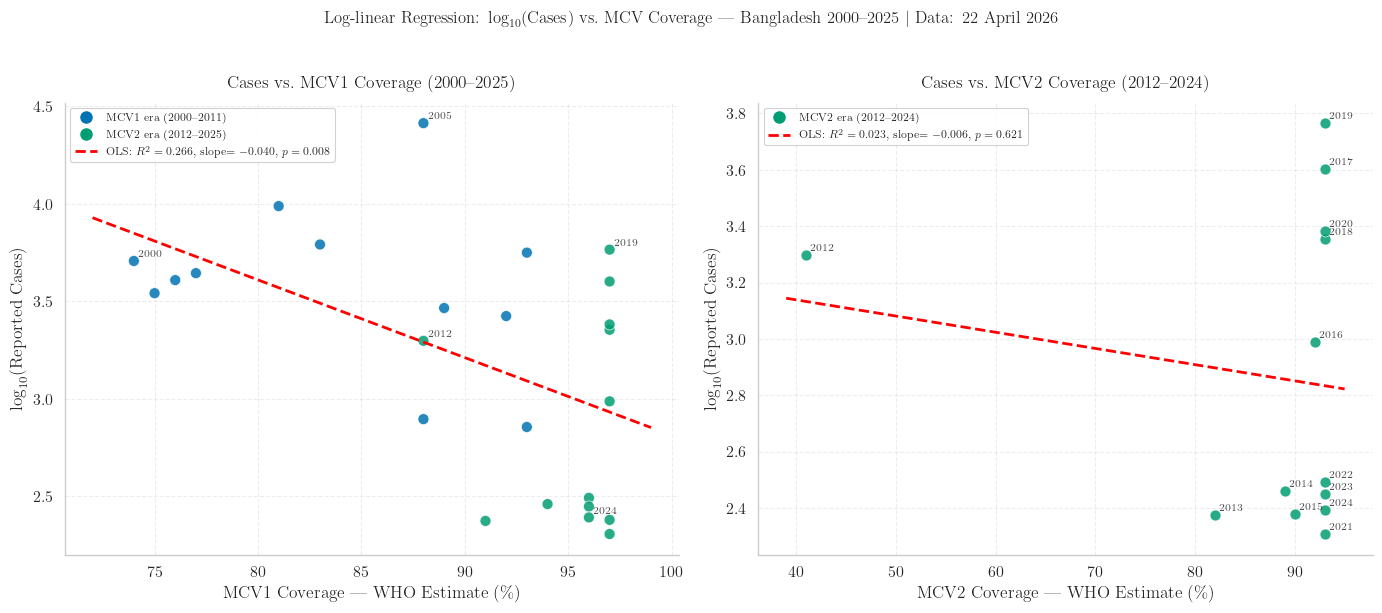

In [23]:
# Figure 18 --- Log-linear regression: coverage vs reported cases
from scipy.stats import linregress as _lr
from matplotlib.lines import Line2D

reg = analysis.copy()
reg['Log_Cases'] = np.log10(
    pd.to_numeric(reg['Reported_Cases'], errors='coerce').clip(lower=1))

m1 = reg.dropna(subset=['MCV1_WHO_%', 'Log_Cases'])
m2 = reg.dropna(subset=['MCV2_WHO_%', 'Log_Cases'])

sl1, ic1, r1, p1, _ = _lr(m1['MCV1_WHO_%'], m1['Log_Cases'])
sl2, ic2, r2, p2, _ = _lr(m2['MCV2_WHO_%'], m2['Log_Cases'])

print(f'log10(Cases) ~ MCV1 WHO: slope={sl1:.4f},  R\u00b2={r1**2:.3f},  p={p1:.4f}')
print(f'log10(Cases) ~ MCV2 WHO: slope={sl2:.4f},  R\u00b2={r2**2:.3f},  p={p2:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── MCV1 panel ───────────────────────────────────────────────────────────
era_col_pts = [BLUE if y <= 2011 else GREEN for y in m1['Year']]
axes[0].scatter(m1['MCV1_WHO_%'], m1['Log_Cases'],
                c=era_col_pts, s=62, alpha=0.85,
                edgecolors='white', lw=0.5, zorder=3)
x1 = np.linspace(m1['MCV1_WHO_%'].min() - 2,
                 m1['MCV1_WHO_%'].max() + 2, 120)
axes[0].plot(x1, ic1 + sl1 * x1, color='red', lw=2, ls='--', zorder=4)

for _, row in m1.iterrows():
    if int(row['Year']) in [2000, 2005, 2012, 2019, 2024, 2025]:
        axes[0].annotate(
            str(int(row['Year'])),
            xy=(row['MCV1_WHO_%'], row['Log_Cases']),
            xytext=(3, 3), textcoords='offset points',
            fontsize=7.5, color='#444444')

axes[0].set_xlabel(r'MCV1 Coverage --- WHO Estimate (\%)')
axes[0].set_ylabel(r'$\log_{10}(\mathrm{Reported~Cases})$')
axes[0].set_title(r'Cases vs.\ MCV1 Coverage (2000--2025)',
                  fontweight='bold', pad=10)

legend_pts = [
    Line2D([0],[0], marker='o', ls='', color=BLUE,  ms=8,
           label=r'MCV1 era (2000--2011)'),
    Line2D([0],[0], marker='o', ls='', color=GREEN, ms=8,
           label=r'MCV2 era (2012--2025)'),
    Line2D([0],[0], ls='--', color='red', lw=2,
           label=(fr'OLS: $R^2={r1**2:.3f}$, '
                  fr'slope$={sl1:.3f}$, $p={p1:.3f}$')),
]
axes[0].legend(handles=legend_pts, framealpha=0.9, fontsize=8)
sns.despine(ax=axes[0])

# ── MCV2 panel ───────────────────────────────────────────────────────────
axes[1].scatter(m2['MCV2_WHO_%'], m2['Log_Cases'],
                c=GREEN, s=62, alpha=0.85,
                edgecolors='white', lw=0.5, zorder=3)
x2 = np.linspace(m2['MCV2_WHO_%'].min() - 2,
                 m2['MCV2_WHO_%'].max() + 2, 120)
axes[1].plot(x2, ic2 + sl2 * x2, color='red', lw=2, ls='--', zorder=4)

for _, row in m2.iterrows():
    axes[1].annotate(
        str(int(row['Year'])),
        xy=(row['MCV2_WHO_%'], row['Log_Cases']),
        xytext=(3, 3), textcoords='offset points',
        fontsize=7.5, color='#444444')

axes[1].set_xlabel(r'MCV2 Coverage --- WHO Estimate (\%)')
axes[1].set_ylabel(r'$\log_{10}(\mathrm{Reported~Cases})$')
axes[1].set_title(r'Cases vs.\ MCV2 Coverage (2012--2024)',
                  fontweight='bold', pad=10)
legend_pts2 = [
    Line2D([0],[0], marker='o', ls='', color=GREEN, ms=8,
           label=r'MCV2 era (2012--2024)'),
    Line2D([0],[0], ls='--', color='red', lw=2,
           label=(fr'OLS: $R^2={r2**2:.3f}$, '
                  fr'slope$={sl2:.3f}$, $p={p2:.3f}$')),
]
axes[1].legend(handles=legend_pts2, framealpha=0.9, fontsize=8)
sns.despine(ax=axes[1])

fig.suptitle(
    r'Log-linear Regression: $\log_{10}(\mathrm{Cases})$ vs.\ '
    r'MCV Coverage --- Bangladesh 2000--2025'
    + f' $|$ Data: {DATA_DATE}',
    fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig18_regression_coverage_cases.png')


---
## Figure Index

| Figure | Description |
|--------|-------------|
| fig01 | Choropleth map --- 2026 cases by division (YlOrRd, compass, scale bar) |
| fig02 | Choropleth map --- 2026 CFR (\%) by division (YlOrRd, compass, scale bar) |
| fig03 | Choropleth map --- 2026 incidence rate per 100{,}000 by division (BBS 2022 pop.) |
| fig04 | 2026 outbreak case cascade --- absolute counts and \% of suspected cases |
| fig05 | 2026 outbreak --- age distribution of deaths (bar $+$ donut) |
| fig06 | 2026 outbreak --- cases and CFR (\%) by division (horizontal bars) |
| fig07 | PairGrid --- 2026 district outbreak: scatter \| KDE contour \| KDE diagonal; axes: Cases, Deaths, CFR (\%), $\log_{10}$(Cases), $\log_{10}$(Deaths$+$1) |
| fig08 | MCV1 coverage (3 sources) and reported cases --- MCV1 era (2000--2011) |
| fig09 | Immunity gap vs.\ measles burden --- red bars where coverage $<$ 95\% |
| fig10 | Effective reproduction number $R_t$ from coverage data (2000--2025) |
| fig11 | MCV1 and MCV2 coverage by source --- MCV2 era (2012--2025) |
| fig12 | Coverage source discrepancy --- administrative vs.\ official vs.\ WHO |
| fig13 | Measles cases and incidence rate (per 100{,}000) with policy milestones (2000--2025) |
| fig14 | Era comparison boxplot --- MCV1-only vs.\ MCV2 era (Mann--Whitney $U$) |
| fig15 | Cases averted by MCV2 --- counterfactual log-linear trend analysis |
| fig16 | Estimated vaccination gap --- annual and cumulative unprotected children |
| fig17 | Pearson correlation heatmap --- cases vs.\ MCV1/MCV2 coverage (2000--2026) |
| fig18 | Log-linear regression: $\log_{10}(\mathrm{Cases})$ vs.\ MCV1 and MCV2 coverage |
